# CityBrain v15 — SMOTE-Only + Regularised Meta-Learner

**COMP 9130 Final Project — Vancouver Pavement Risk Assessment**

| Change | v13 | v14 | v15 |
|--------|-----|-----|-----|
| Resampling | SMOTE-ENN (crushed Medium) | None | **SMOTE only** |
| Meta-learner | depth=3, no reg | depth=3, no reg | **depth=2, regularised** |
| Best F1 | 0.5452 | 0.5332 | ? |

**Architecture:** Road-MLP + Tabular-MLP → Transformer Fusion → 10-Fold Stacking → Meta-Learner → Threshold Tuning

## 0. Setup & Imports

Import all libraries, mount Google Drive, define constants and label mapping.

In [1]:
import os, ast, json, warnings
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
warnings.filterwarnings('ignore')

# --- Colab ---
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/AI-FinalProject/data'

SNAP_RADIUS_M = 150
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

LABEL_MAP = {
    'VERY GOOD': 0,
    'GOOD': 1, 'FAIR': 1,
    'POOR': 2, 'VERY POOR': 2,
}
NUM_CLASSES = 3
CLASS_NAMES = ['Low', 'Medium', 'High']

def safe_load(filename, **kwargs):
    path = os.path.join(DATA_DIR, filename) if not os.path.isabs(filename) else filename
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        first = f.readline()
    sep = ';' if first.count(';') > first.count(',') else ','
    return pd.read_csv(path, sep=sep, on_bad_lines='skip', **kwargs)

print(f'Label mapping: {LABEL_MAP}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Mounted at /content/drive
Device: cuda
Label mapping: {'VERY GOOD': 0, 'GOOD': 1, 'FAIR': 1, 'POOR': 2, 'VERY POOR': 2}
Classes (3): ['Low', 'Medium', 'High']


## 1. Load Pavement Data & Basic Spatial Features

Load `pavement_enriched.csv`, compute street use classification, ROW width, repair count, etc.

In [2]:
enriched_path = '/content/drive/MyDrive/AI-FinalProject/data/pavement_enriched.csv'
if os.path.exists(enriched_path):
    df = pd.read_csv(enriched_path)
    print(f'Loaded pavement_enriched.csv: {len(df):,} rows')
else:
    df_local = safe_load('pavement_condition.csv'); df_local['road_type'] = 'local'
    df_major = safe_load('pavement_condition_major_road_network.csv'); df_major['road_type'] = 'major'
    df = pd.concat([df_local, df_major], ignore_index=True)
    coords = df['geo_point_2d'].str.split(',', expand=True).astype(float)
    df['lat'], df['lon'] = coords[0], coords[1]

df = df[df['PCI Rating'].isin(LABEL_MAP)].copy()
df['risk_label'] = df['PCI Rating'].map(LABEL_MAP)
df['source'] = (df['road_type'] == 'major').astype(int) if 'road_type' in df.columns else 0
print(f'Total samples: {len(df):,} (ALL kept)')
for v, name in enumerate(CLASS_NAMES):
    cnt = (df['risk_label']==v).sum()
    print(f'  {v} ({name}): {cnt:,} ({cnt/len(df)*100:.1f}%)')

pave_coords = np.column_stack([df['lat'].values, df['lon'].values])
LAT_M, LON_M = 111_000, 73_000

Loaded pavement_enriched.csv: 13,764 rows
Total samples: 13,764 (ALL kept)
  0 (Low): 3,247 (23.6%)
  1 (Medium): 5,894 (42.8%)
  2 (High): 4,623 (33.6%)


In [3]:
# --- streetuse ---
df_st = pd.read_csv('/content/drive/MyDrive/AI-FinalProject/data/public_streets.csv',
                     quotechar='"', on_bad_lines='skip')
st_geo = df_st['geo_point_2d'].dropna().apply(ast.literal_eval)
st_coords = np.array([[d['lat'], d['lon']] for d in st_geo])
_, idx = cKDTree(st_coords).query(pave_coords)
df['streetuse'] = df_st.loc[st_geo.index, 'streetuse'].values[idx]
STREETUSE_WEIGHT = {'Residential': 0.3, 'Collector': 0.6, 'Arterial': 1.0}
df['streetuse_weight'] = df['streetuse'].map(STREETUSE_WEIGHT).fillna(0.5)

# --- ROW width ---
df_row = safe_load('right_of_way_widths.csv')
geo_col = [c for c in df_row.columns if 'geo_point' in c.lower()][0]
width_col = [c for c in df_row.columns if 'width' in c.lower()][0]
row_geo = df_row[geo_col].dropna().apply(lambda s: ast.literal_eval(s) if '{' in str(s) else s)
row_coords = np.array([[d['lat'], d['lon']] for d in row_geo if isinstance(d, dict)])
row_widths = pd.to_numeric(df_row.loc[row_geo.index[:len(row_coords)], width_col], errors='coerce').fillna(0).values
_, idx = cKDTree(row_coords).query(pave_coords)
df['ROW_width'] = row_widths[idx]

In [4]:
# --- repair_count ---
df['repair_count'] = 0
repair_path = '/content/drive/MyDrive/AI-FinalProject/data/city_project_package_street.csv'
if os.path.exists(repair_path):
    df_repair = safe_load('city_project_package_street.csv')
    geo_cols = [c for c in df_repair.columns if 'geo_point' in c.lower()]
    if geo_cols:
        try:
            rg = df_repair[geo_cols[0]].dropna()
            parsed = rg.apply(lambda s: ast.literal_eval(s) if '{' in str(s) else s)
            rc = np.array([[d['lat'], d['lon']] for d in parsed if isinstance(d, dict)])
            counts = cKDTree(rc * [LAT_M, LON_M]).query_ball_point(pave_coords * [LAT_M, LON_M], r=100)
            df['repair_count'] = [len(c) for c in counts]
        except: pass

In [5]:
# --- segment_density ---
tree_all = cKDTree(pave_coords)
neighbours = tree_all.query_ball_point(pave_coords, r=0.003)
df['segment_density'] = [len(n) - 1 for n in neighbours]

# --- elevation & slope ---
if 'elevation_m' not in df.columns:
    df['elevation_m'] = 0.0; df['slope_pct'] = 0.0
df['elevation_m'] = df['elevation_m'].fillna(df['elevation_m'].median())
df['slope_pct'] = df['slope_pct'].fillna(df['slope_pct'].median())

# --- neighbourhood ---
df['neighbourhood'] = df.get('neighbourhood', pd.Series('Unknown', index=df.index)).fillna('Unknown')

# --- traffic counter distance ---
df_traffic = safe_load('directional_traffic_count_locations.csv')
traf_geo_col = [c for c in df_traffic.columns if 'geo_point' in c.lower()][0]
traf_geo = df_traffic[traf_geo_col].dropna().apply(lambda s: ast.literal_eval(s) if '{' in str(s) else s)
traf_coords = np.array([[d['lat'], d['lon']] for d in traf_geo if isinstance(d, dict)])
traf_dists, _ = cKDTree(traf_coords * [LAT_M, LON_M]).query(pave_coords * [LAT_M, LON_M])
df['dist_to_traffic_count'] = traf_dists

print(f'Static features ready.')

Static features ready.


## 1b. Infrastructure Spatial Features

Compute proximity-based features from 10 infrastructure datasets:
water mains, sewers, trees, truck routes, zoning, bikeways, permits, manholes, catch basins, snow routes, transit.

In [6]:
print('\n--- Computing Infrastructure Spatial Features ---')

def parse_geo_points(series):
    """Parse 'lat, lon' strings to numpy array of [lat, lon]."""
    valid = series.dropna()
    coords = valid.str.split(',', expand=True).astype(float)
    return coords.values, valid.index

def parse_line_geometry(geom_series):
    """Extract all coordinate points from LineString/MultiLineString GeoJSON."""
    pts = []
    for geom_str in geom_series.dropna():
        try:
            geom = json.loads(geom_str.replace('""', '"').strip('"'))
            if geom['type'] == 'MultiLineString':
                for line in geom['coordinates']:
                    pts.extend([[pt[1], pt[0]] for pt in line])
            elif geom['type'] == 'LineString':
                pts.extend([[pt[1], pt[0]] for pt in geom['coordinates']])
        except:
            pass
    return np.array(pts) if pts else np.empty((0, 2))


--- Computing Infrastructure Spatial Features ---


In [7]:
# --- Water Distribution Mains (67K lines) ---
print('  Water mains...')
df_water = safe_load('water_distribution_mains.csv')
w_coords, w_idx = parse_geo_points(df_water['geo_point_2d'])
w_tree = cKDTree(w_coords * [LAT_M, LON_M])
w_near = w_tree.query_ball_point(pave_coords * [LAT_M, LON_M], r=50)
df['water_main_count'] = [len(n) for n in w_near]
w_install = pd.to_datetime(df_water.loc[w_idx, 'INSTALLATION_DATE'], errors='coerce')
w_ages = (2024 - w_install.dt.year).values.astype(float)
water_avg_age = []
for neighbors in w_near:
    if len(neighbors) > 0:
        ages = w_ages[neighbors]
        valid = ages[~np.isnan(ages)]
        water_avg_age.append(float(np.mean(valid)) if len(valid) > 0 else 0.0)
    else:
        water_avg_age.append(0.0)
df['water_main_avg_age'] = water_avg_age
print(f'    {(df["water_main_count"] > 0).sum():,} segments have nearby water mains')

  Water mains...
    13,291 segments have nearby water mains


In [8]:
# --- Sewer Mains (40K lines) ---
print('  Sewer mains...')
df_sewer = safe_load('sewer_mains.csv')
s_coords, s_idx = parse_geo_points(df_sewer['geo_point_2d'])
s_tree = cKDTree(s_coords * [LAT_M, LON_M])
s_near = s_tree.query_ball_point(pave_coords * [LAT_M, LON_M], r=50)
df['sewer_main_count'] = [len(n) for n in s_near]
s_types = df_sewer.loc[s_idx, 'Effluent Type'].values
sewer_combined_pct = []
for neighbors in s_near:
    if len(neighbors) > 0:
        sewer_combined_pct.append(float(np.mean(s_types[neighbors] == 'Combined')))
    else:
        sewer_combined_pct.append(0.0)
df['sewer_combined_pct'] = sewer_combined_pct
print(f'    {(df["sewer_main_count"] > 0).sum():,} segments have nearby sewer mains')

  Sewer mains...
    12,829 segments have nearby sewer mains


In [9]:
# --- Public Trees (186K points — root damage) ---
print('  Trees...')
df_trees = safe_load('public_trees.csv')
t_coords, t_idx = parse_geo_points(df_trees['geo_point_2d'])
t_tree_kd = cKDTree(t_coords * [LAT_M, LON_M])
t_near = t_tree_kd.query_ball_point(pave_coords * [LAT_M, LON_M], r=30)
df['tree_count_30m'] = [len(n) for n in t_near]
t_diam = pd.to_numeric(df_trees.loc[t_idx, 'diameter_(cm)'], errors='coerce').values
t_height = pd.to_numeric(df_trees.loc[t_idx, 'height_(m)'], errors='coerce').values
tree_avg_diam, tree_avg_height = [], []
for neighbors in t_near:
    if len(neighbors) > 0:
        d = t_diam[neighbors]; d = d[~np.isnan(d)]
        h = t_height[neighbors]; h = h[~np.isnan(h)]
        tree_avg_diam.append(float(np.mean(d)) if len(d) > 0 else 0.0)
        tree_avg_height.append(float(np.mean(h)) if len(h) > 0 else 0.0)
    else:
        tree_avg_diam.append(0.0); tree_avg_height.append(0.0)
df['tree_avg_diameter'] = tree_avg_diam
df['tree_avg_height'] = tree_avg_height
print(f'    {(df["tree_count_30m"] > 0).sum():,} segments have nearby trees')

  Trees...
    11,894 segments have nearby trees


In [10]:
# --- Truck Routes (heavy axle load → 4th power damage) ---
print('  Truck routes...')
df_truck = safe_load('truck_routes.csv')
truck_pts = parse_line_geometry(df_truck['Geom'])
if len(truck_pts) > 0:
    truck_kd = cKDTree(truck_pts * [LAT_M, LON_M])
    truck_dists, _ = truck_kd.query(pave_coords * [LAT_M, LON_M])
    df['is_truck_route'] = (truck_dists < 50).astype(int)
else:
    df['is_truck_route'] = 0
print(f'    {df["is_truck_route"].sum():,} segments on truck routes')

# --- Zoning Districts (land use) ---
print('  Zoning...')
df_zone = safe_load('zoning_districts.csv')
z_coords, z_idx = parse_geo_points(df_zone['geo_point_2d'])
z_tree = cKDTree(z_coords * [LAT_M, LON_M])
_, z_nearest = z_tree.query(pave_coords * [LAT_M, LON_M])
z_cat_col = [c for c in df_zone.columns if 'category' in c.lower()][0]
z_categories = df_zone.loc[z_idx, z_cat_col].values
df['zoning_category'] = z_categories[z_nearest]
df['is_industrial'] = (df['zoning_category'] == 'I').astype(int)
df['is_commercial'] = df['zoning_category'].isin(['C', 'FC']).astype(int)
print(f'    Industrial: {df["is_industrial"].sum():,}  Commercial: {df["is_commercial"].sum():,}')

  Truck routes...
    4,495 segments on truck routes
  Zoning...
    Industrial: 242  Commercial: 2,494


In [11]:
# --- Bikeways (speed limit, road type proxy) ---
print('  Bikeways...')
df_bike = safe_load('bikeways.csv')
b_coords, b_idx = parse_geo_points(df_bike['geo_point_2d'])
b_tree = cKDTree(b_coords * [LAT_M, LON_M])
b_dists, b_nearest = b_tree.query(pave_coords * [LAT_M, LON_M])
df['is_bikeway'] = (b_dists < 50).astype(int)
speed_col = [c for c in df_bike.columns if 'speed' in c.lower()][0]
b_speed = pd.to_numeric(df_bike.loc[b_idx, speed_col], errors='coerce').fillna(50).values
df['speed_limit'] = np.where(b_dists < 100, b_speed[b_nearest], 50).astype(float)
print(f'    {df["is_bikeway"].sum():,} segments near bikeways')

# --- Building Permits (625K — construction = heavy trucks + utility cuts) ---
print('  Building permits...')
df_perm = safe_load('building_permits.csv', low_memory=False)
p_coords, p_idx = parse_geo_points(df_perm['geo_point_2d'])
yr_col = [c for c in df_perm.columns if 'issueyear' in c.lower() or 'issue_year' in c.lower()][0]
p_years = pd.to_numeric(df_perm.loc[p_idx, yr_col], errors='coerce').values
recent_mask = (p_years >= 2018) & (p_years <= 2024)
p_coords_recent = p_coords[recent_mask]
val_col = [c for c in df_perm.columns if 'value' in c.lower()][0]
p_values = pd.to_numeric(df_perm.loc[p_idx, val_col], errors='coerce').fillna(0).values[recent_mask]
if len(p_coords_recent) > 0:
    p_tree = cKDTree(p_coords_recent * [LAT_M, LON_M])
    p_near = p_tree.query_ball_point(pave_coords * [LAT_M, LON_M], r=200)
    df['permit_count_200m'] = [len(n) for n in p_near]
    df['permit_avg_value'] = [float(np.mean(p_values[n])) if len(n) > 0 else 0.0 for n in p_near]
else:
    df['permit_count_200m'] = 0; df['permit_avg_value'] = 0.0
print(f'    {(df["permit_count_200m"] > 0).sum():,} segments have nearby permits')

  Bikeways...
    2,928 segments near bikeways
  Building permits...
    13,670 segments have nearby permits


In [12]:
# --- Sewer Manholes (36K points — pavement weak points) ---
print('  Manholes...')
df_mh = safe_load('sewer_manholes.csv')
mh_coords, mh_idx = parse_geo_points(df_mh['geo_point_2d'])
mh_tree = cKDTree(mh_coords * [LAT_M, LON_M])
mh_near = mh_tree.query_ball_point(pave_coords * [LAT_M, LON_M], r=50)
df['manhole_count_50m'] = [len(n) for n in mh_near]
print(f'    {(df["manhole_count_50m"] > 0).sum():,} segments have nearby manholes')

# --- Sewer Catch Basins (45K points — drainage quality) ---
print('  Catch basins...')
df_cb = safe_load('sewer_catch_basins.csv')
cb_coords, cb_idx = parse_geo_points(df_cb['geo_point_2d'])
cb_tree = cKDTree(cb_coords * [LAT_M, LON_M])
cb_near = cb_tree.query_ball_point(pave_coords * [LAT_M, LON_M], r=50)
df['catch_basin_count_50m'] = [len(n) for n in cb_near]
print(f'    {(df["catch_basin_count_50m"] > 0).sum():,} segments have nearby catch basins')

  Manholes...
    12,317 segments have nearby manholes
  Catch basins...
    12,378 segments have nearby catch basins


In [13]:
# --- Snow Removal Routes (salt + plow damage) ---
print('  Snow removal routes...')
df_snow = safe_load('snow_removal_routes.csv')
snow_pts = parse_line_geometry(df_snow['Geom'])
if len(snow_pts) > 0:
    snow_kd = cKDTree(snow_pts * [LAT_M, LON_M])
    snow_dists, _ = snow_kd.query(pave_coords * [LAT_M, LON_M])
    df['is_snow_route'] = (snow_dists < 50).astype(int)
else:
    df['is_snow_route'] = 0
print(f'    {df["is_snow_route"].sum():,} segments on snow removal routes')

# --- Transit Bus Frequency (GTFS — heavy bus = road damage) ---
print('  Transit (GTFS)...')
gtfs_dir = os.path.join(DATA_DIR, 'translink_gtfs')
if os.path.exists(os.path.join(gtfs_dir, 'shapes.txt')):
    df_shapes = pd.read_csv(os.path.join(gtfs_dir, 'shapes.txt'))
    df_trips = pd.read_csv(os.path.join(gtfs_dir, 'trips.txt'))
    trips_per_shape = df_trips.groupby('shape_id').size().to_dict()
    df_shapes_sub = df_shapes.iloc[::5].copy()
    shape_coords = df_shapes_sub[['shape_pt_lat', 'shape_pt_lon']].values
    shape_ids = df_shapes_sub['shape_id'].values
    bus_tree = cKDTree(shape_coords * [LAT_M, LON_M])
    bus_near = bus_tree.query_ball_point(pave_coords * [LAT_M, LON_M], r=50)
    bus_freq = []
    for neighbors in bus_near:
        if len(neighbors) > 0:
            nearby_shapes = set(shape_ids[neighbors])
            bus_freq.append(sum(trips_per_shape.get(s, 0) for s in nearby_shapes))
        else:
            bus_freq.append(0)
    df['bus_frequency'] = bus_freq
else:
    df['bus_frequency'] = 0
print(f'    {(df["bus_frequency"] > 0).sum():,} segments near bus routes')

  Snow removal routes...
    3,040 segments on snow removal routes
  Transit (GTFS)...
    5,081 segments near bus routes


In [14]:
infra_feats = ['water_main_count','water_main_avg_age','sewer_main_count','sewer_combined_pct',
               'tree_count_30m','tree_avg_diameter','tree_avg_height','is_truck_route',
               'is_industrial','is_commercial','is_bikeway','speed_limit',
               'permit_count_200m','permit_avg_value','manhole_count_50m',
               'catch_basin_count_50m','is_snow_route','bus_frequency']
print(f'\n  Infrastructure features added: {len(infra_feats)} new columns')

# *** v12: Proxy features + density normalization + domain interactions ***
print('\n--- Computing Proxy & Domain Features (v12) ---')

# 1. Estimated pavement age proxy from water main age
#    ★ v14: per-streetuse median fill + imputation indicator ★
df['est_age_imputed'] = ((df['water_main_avg_age'] <= 0) | df['water_main_avg_age'].isna()).astype(int)
df['est_pavement_age'] = df['water_main_avg_age'].clip(lower=0, upper=80)
# Per-streetuse median (Arterial/Collector/Residential have different typical ages)
streetuse_medians = df.loc[df['water_main_avg_age'] > 0].groupby('streetuse')['water_main_avg_age'].median()
global_median = df.loc[df['water_main_avg_age'] > 0, 'water_main_avg_age'].median()
for su, med in streetuse_medians.items():
    mask = (df['streetuse'] == su) & ((df['est_pavement_age'] <= 0) | df['est_pavement_age'].isna())
    df.loc[mask, 'est_pavement_age'] = med
df['est_pavement_age'] = df['est_pavement_age'].replace(0, global_median).fillna(global_median)
print(f'  Estimated pavement age: mean={df["est_pavement_age"].mean():.1f} yrs')
print(f'  est_age_imputed: {df["est_age_imputed"].sum()} / {len(df)} ({df["est_age_imputed"].mean()*100:.1f}%) imputed')
print(f'  Per-streetuse medians: {dict(streetuse_medians.round(1))}')


  Infrastructure features added: 18 new columns

--- Computing Proxy & Domain Features (v12) ---
  Estimated pavement age: mean=46.9 yrs
  est_age_imputed: 534 / 13764 (3.9%) imputed
  Per-streetuse medians: {'Arterial': np.float64(49.0), 'Collector': np.float64(56.0), 'Residential': np.float64(45.3)}


In [15]:
# 2. Traffic load proxy combining streetuse, bus freq, truck route
df['traffic_load_proxy'] = (
    df['streetuse_weight'] * 3.0 +
    np.log1p(df['bus_frequency']) * 0.5 +
    df['is_truck_route'] * 2.0 +
    df['is_snow_route'] * 0.5
)
print(f'  Traffic load proxy: mean={df["traffic_load_proxy"].mean():.2f}')

# 3. Underground utility density (excavation damage proxy)
df['utility_density'] = (
    df['water_main_count'] +
    df['sewer_main_count'] +
    df['manhole_count_50m'] +
    df['catch_basin_count_50m']
)
print(f'  Utility density: mean={df["utility_density"].mean():.1f}')

# 4. Density normalization (count / 100m road length — trees can't learn division)
lengths = df['length_(m)'].fillna(df['length_(m)'].median()).values
safe_len_100m = np.maximum(lengths / 100.0, 0.01)
df['manholes_per_100m'] = df['manhole_count_50m'].values / safe_len_100m
df['trees_per_100m'] = df['tree_count_30m'].values / safe_len_100m
df['water_mains_per_100m'] = df['water_main_count'].values / safe_len_100m
df['catch_basins_per_100m'] = df['catch_basin_count_50m'].values / safe_len_100m
print(f'  Density features (per 100m): manholes, trees, water_mains, catch_basins')

  Traffic load proxy: mean=3.88
  Utility density: mean=19.0
  Density features (per 100m): manholes, trees, water_mains, catch_basins


In [16]:
# 5. Domain-specific interactions (physical meaning, not just products)
df['tree_root_pressure'] = df['tree_count_30m'] * df['tree_avg_diameter']  # big trees = strong roots
df['drainage_risk'] = 0.0  # updated after weather section (sewer_combined × precip)
df['pipe_freeze_risk'] = 0.0  # updated after weather section (old pipes × freeze)

proxy_feats = ['est_pavement_age', 'est_age_imputed', 'traffic_load_proxy', 'utility_density',
               'manholes_per_100m', 'trees_per_100m', 'water_mains_per_100m',
               'catch_basins_per_100m', 'tree_root_pressure',
               'drainage_risk', 'pipe_freeze_risk']
print(f'  Proxy + domain features added: {len(proxy_feats)}')

  Proxy + domain features added: 11


## 2. Train / Val / Test Split (70/15/15)

Stratified split to maintain class proportions.

In [17]:
y = df['risk_label'].values
indices = np.arange(len(df))
idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42, stratify=y)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42, stratify=y[idx_temp])
print(f'Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}')

Train: 9,634  Val: 2,065  Test: 2,065


## 3. Multi-Scale Spatial Lag (3/7/15-NN)

Distance-weighted risk scores from K nearest training neighbours — captures spatial autocorrelation.

In [18]:
print('\n--- Computing Multi-Scale Spatial Lag Features ---')
train_coords_m = pave_coords[idx_train] * [LAT_M, LON_M]
all_coords_m   = pave_coords * [LAT_M, LON_M]
train_tree_sl  = cKDTree(train_coords_m)
train_labels   = y[idx_train]

nn_k_7 = None
sl_weights_n_7 = None

for K in [3, 7, 15]:
    dists_k, nn_k = train_tree_sl.query(all_coords_m, k=K + 1)
    self_match = dists_k[:, 0] < 0.01
    dists_k = np.where(self_match[:, None], dists_k[:, 1:K+1], dists_k[:, :K])
    nn_k    = np.where(self_match[:, None], nn_k[:, 1:K+1],    nn_k[:, :K])

    sl_weights   = 1.0 / (dists_k + 1e-6)
    sl_weights_n = sl_weights / sl_weights.sum(axis=1, keepdims=True)
    neighbour_labs = train_labels[nn_k]

    df[f'spatial_lag_risk_{K}']  = (sl_weights_n * neighbour_labs).sum(axis=1)
    df[f'spatial_lag_high_{K}']  = (sl_weights_n * (neighbour_labs == 2)).sum(axis=1)
    if K == 7:
        df[f'spatial_lag_med_{K}'] = (sl_weights_n * (neighbour_labs == 1)).sum(axis=1)
        nn_k_7, sl_weights_n_7 = nn_k.copy(), sl_weights_n.copy()

    if K == 3:
        print(f'  Self-matches removed: {self_match.sum()} / {len(self_match)}')
    m = df[f'spatial_lag_risk_{K}']
    print(f'  {K}-NN: risk mean={m.mean():.3f} std={m.std():.3f}')


--- Computing Multi-Scale Spatial Lag Features ---
  Self-matches removed: 9634 / 13764
  3-NN: risk mean=1.096 std=0.550
  7-NN: risk mean=1.099 std=0.453
  15-NN: risk mean=1.099 std=0.383


## 4. Neighbourhood Target Encoding

Per-neighbourhood risk proportions from **training data only** (no leakage).

In [19]:
print('\n--- Computing Neighbourhood Target Encoding ---')
train_df = df.iloc[idx_train]
for cls, name in [(0, 'neigh_low_pct'), (1, 'neigh_med_pct'), (2, 'neigh_high_pct')]:
    d = train_df.groupby('neighbourhood')['risk_label'].apply(
        lambda x: (x == cls).mean()).to_dict()
    global_rate = (train_df['risk_label'] == cls).mean()
    df[name] = df['neighbourhood'].map(d).fillna(global_rate)


--- Computing Neighbourhood Target Encoding ---


## 5. Weather & 311 Complaint Features

Weather aggregates + road interactions, 311 complaint counts + spatial lag.

In [20]:
print('\n--- Computing Weather & 311 Static Features ---')

# --- Weather ---
df_w = safe_load('weather_vancouver.csv')
date_col = [c for c in df_w.columns if 'date' in c.lower() or 'time' in c.lower()][0]
df_w['date'] = pd.to_datetime(df_w[date_col], errors='coerce')
df_w = df_w.dropna(subset=['date'])
col_map = {}
for c in df_w.columns:
    cl = c.lower().strip()
    if 'max temp' in cl and 'flag' not in cl: col_map[c] = 'max_temp'
    elif 'min temp' in cl and 'flag' not in cl: col_map[c] = 'min_temp'
    elif 'total precip' in cl and 'flag' not in cl: col_map[c] = 'total_precip'
    elif 'total snow' in cl and 'flag' not in cl: col_map[c] = 'total_snow'
df_w = df_w.rename(columns=col_map)
for c in ['max_temp','min_temp','total_precip','total_snow']:
    if c in df_w.columns: df_w[c] = pd.to_numeric(df_w[c], errors='coerce').fillna(0)
df_w['freeze_thaw'] = ((df_w['max_temp'] > 0) & (df_w['min_temp'] < 0)).astype(int)
df_w['extreme'] = (df_w['total_precip'] > df_w['total_precip'].quantile(0.95)).astype(int)
df_w['year'] = df_w['date'].dt.year


--- Computing Weather & 311 Static Features ---


In [21]:
annual_wx = df_w.groupby('year').agg(
    annual_precip=('total_precip', 'sum'),
    annual_snow=('total_snow', 'sum'),
    annual_freeze=('freeze_thaw', 'sum'),
    annual_extreme=('extreme', 'sum'),
    annual_temp_range=('max_temp', lambda x: x.mean() - df_w.loc[x.index, 'min_temp'].mean()),
).to_dict('index')
print(f'Weather years available: {sorted(annual_wx.keys())}')

years = df['Year'].values if 'Year' in df.columns else np.full(len(df), 2020)
slopes = df['slope_pct'].values
su_weights_arr = df['streetuse_weight'].values

for feat in ['annual_precip', 'annual_snow', 'annual_freeze', 'annual_extreme', 'annual_temp_range']:
    df[feat] = [annual_wx.get(yr, {}).get(feat, 0) for yr in years]

df['prev_yr_precip'] = [annual_wx.get(yr - 1, {}).get('annual_precip', 0) for yr in years]
df['prev_yr_freeze'] = [annual_wx.get(yr - 1, {}).get('annual_freeze', 0) for yr in years]

# Weather × road interactions
df['precip_x_slope']     = df['annual_precip'] * slopes
df['freeze_x_street']    = df['annual_freeze'] * su_weights_arr
df['snow_x_slope']       = df['annual_snow'] * slopes
df['temprange_x_street'] = df['annual_temp_range'] * su_weights_arr

Weather years available: [2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [22]:
# NOW update v12 domain interactions (weather data is now available)
df['drainage_risk'] = df['sewer_combined_pct'] * df['annual_precip']  # combined sewer + rain = flooding
df['pipe_freeze_risk'] = df['water_main_avg_age'] * df['annual_freeze']  # old pipes + freeze = burst
print(f'  Domain interactions updated: drainage_risk, pipe_freeze_risk')

print(f'  Weather: 7 aggregates + 4 interactions = 11')

# --- 311 ---
print('\nLoading 311...')
df_311 = safe_load('311_service_requests_2009_2021.csv', low_memory=False)
id_cols = [c for c in df_311.columns if 'case' in c.lower() or 'id' in c.lower()]
if id_cols: df_311 = df_311.drop_duplicates(subset=id_cols[0])
PAVEMENT_TYPES = [
    'Pothole Case', 'Street Repair Case', 'Sidewalk Repair Case',
    'Pavement Marking Maintenance Case', 'Pavement Markings Case',
    'Street Surface Water Flooding Case', 'Street Construction Concern Case',
    'Street Cleaning and Debris Pick Up Case', 'Curb Ramp Request Case',
]
type_col = 'Service request type'
df_311 = df_311[df_311[type_col].isin(PAVEMENT_TYPES)]
print(f'  Pavement-related: {len(df_311):,}')

  Domain interactions updated: drainage_risk, pipe_freeze_risk
  Weather: 7 aggregates + 4 interactions = 11

Loading 311...
  Pavement-related: 135,647


In [23]:
date_cols = [c for c in df_311.columns if 'open' in c.lower() or 'timestamp' in c.lower() or 'created' in c.lower()]
if not date_cols: date_cols = [c for c in df_311.columns if 'date' in c.lower()]
df_311['date'] = pd.to_datetime(df_311[date_cols[0]], errors='coerce', utc=True)
lat_col = [c for c in df_311.columns if c.lower() in ['latitude','lat']]
lon_col = [c for c in df_311.columns if c.lower() in ['longitude','lon']]
if lat_col and lon_col:
    df_311['c_lat'] = pd.to_numeric(df_311[lat_col[0]], errors='coerce')
    df_311['c_lon'] = pd.to_numeric(df_311[lon_col[0]], errors='coerce')
else:
    geo_col = [c for c in df_311.columns if 'geo_local' in c.lower() or 'geo_point' in c.lower()]
    if geo_col:
        raw = df_311[geo_col[0]].dropna()
        if len(raw) > 0 and '{' in str(raw.iloc[0]):
            parsed = raw.apply(lambda s: ast.literal_eval(s) if isinstance(s, str) else s)
            df_311.loc[raw.index, 'c_lat'] = [d.get('lat',np.nan) if isinstance(d,dict) else np.nan for d in parsed]
            df_311.loc[raw.index, 'c_lon'] = [d.get('lon',np.nan) if isinstance(d,dict) else np.nan for d in parsed]

df_311 = df_311.dropna(subset=['c_lat','c_lon','date'])
df_311['year'], df_311['month'] = df_311['date'].dt.year, df_311['date'].dt.month
survey_years = df['Year'].unique() if 'Year' in df.columns else [2020, 2021]
df_311 = df_311[df_311['year'].isin(survey_years)]
print(f'  Survey-year 311: {len(df_311):,}')

  Survey-year 311: 27,187


In [24]:
c311_coords = df_311[['c_lat','c_lon']].values
pave_tree_m = cKDTree(pave_coords * [LAT_M, LON_M])
dists_311, snap_idx = pave_tree_m.query(c311_coords * [LAT_M, LON_M])
mask = dists_311 < SNAP_RADIUS_M
df_311 = df_311[mask].copy()
df_311['seg_idx'] = snap_idx[mask]
df_311['is_pothole'] = df_311[type_col].str.contains('Pothole', case=False).astype(int)
print(f'  Snapped within {SNAP_RADIUS_M}m: {len(df_311):,}')

N = len(df)
complaint_total = np.zeros(N)
pothole_total = np.zeros(N)
complaint_recent = np.zeros(N)

for i in range(N):
    yr = years[i]
    seg_c = df_311[(df_311['seg_idx'] == i) & (df_311['year'] == yr)]
    complaint_total[i] = len(seg_c)
    pothole_total[i] = seg_c['is_pothole'].sum()
    complaint_recent[i] = len(seg_c[seg_c['month'] >= 10])

  Snapped within 150m: 27,024


In [25]:
df['complaint_total'] = complaint_total
df['pothole_total'] = pothole_total
df['complaint_recent_3m'] = complaint_recent
df['complaint_accel'] = complaint_recent / np.maximum(complaint_total, 1)

# ★ v9: complaint density (normalize by road length) ★
lengths = df['length_(m)'].fillna(df['length_(m)'].median()).values
df['complaint_density'] = complaint_total / np.maximum(lengths, 1.0)

# Spatial lag of complaint counts (7-NN)
train_complaints = complaint_total[idx_train]
neighbour_compl = train_complaints[nn_k_7]
df['spatial_lag_complaints'] = (sl_weights_n_7 * neighbour_compl).sum(axis=1)

print(f'  Complaint features: total, pothole, recent_3m, accel, density, sl_complaints')
print(f'  complaint_total nonzero: {(complaint_total > 0).sum():,} / {N:,}')

  Complaint features: total, pothole, recent_3m, accel, density, sl_complaints
  complaint_total nonzero: 6,204 / 13,764


## 6. Feature Construction

**Road-MLP** (12d): physical attributes | **Tabular-MLP** (55d+8d emb): contextual + infrastructure features.

In [26]:
print('\n--- Feature Construction (CLEAN SEPARATION) ---')

su_dummies = pd.get_dummies(df['streetuse'], prefix='su')
for c in ['su_Arterial','su_Collector','su_Residential']:
    if c not in su_dummies.columns: su_dummies[c] = 0

# ★ Road-MLP: 12d PURE PHYSICAL — what IS this road ★
X_road_raw = np.column_stack([
    lengths,
    su_dummies[['su_Arterial','su_Collector','su_Residential']].values,
    df['elevation_m'].values,
    df['slope_pct'].values,
    df['source'].values,
    df['ROW_width'].values,
    df['is_truck_route'].values,
    df['is_snow_route'].values,
    df['is_bikeway'].values,
    df['speed_limit'].values,
]).astype(np.float32)


--- Feature Construction (CLEAN SEPARATION) ---


In [27]:
# ★ Tabular-MLP continuous: 55d (44 from v11 + 11 v14 proxy/domain) ★
X_tab_cont_raw = np.column_stack([
    # --- Spatial context (10) ---
    df['repair_count'].values,
    df['segment_density'].values,
    df['dist_to_traffic_count'].values,
    df['spatial_lag_risk_3'].values,
    df['spatial_lag_high_3'].values,
    df['spatial_lag_risk_7'].values,
    df['spatial_lag_high_7'].values,
    df['spatial_lag_med_7'].values,
    df['spatial_lag_risk_15'].values,
    df['spatial_lag_high_15'].values,
    # --- Neighbourhood encoding (3) ---
    df['neigh_low_pct'].values,
    df['neigh_med_pct'].values,
    df['neigh_high_pct'].values,
    # --- Complaints (6) ---
    df['complaint_total'].values,
    df['pothole_total'].values,
    df['complaint_recent_3m'].values,
    df['complaint_accel'].values,
    df['complaint_density'].values,
    df['spatial_lag_complaints'].values,
    # --- Weather (7) ---
    df['annual_precip'].values,
    df['annual_snow'].values,
    df['annual_freeze'].values,
    df['annual_extreme'].values,
    df['annual_temp_range'].values,
    df['prev_yr_precip'].values,
    df['prev_yr_freeze'].values,
    # --- Weather × road interactions (4) ---
    df['precip_x_slope'].values,
    df['freeze_x_street'].values,
    df['snow_x_slope'].values,
    df['temprange_x_street'].values,
    # ★ v11: Infrastructure context (14) ★
    df['water_main_count'].values,
    df['water_main_avg_age'].values,
    df['sewer_main_count'].values,
    df['sewer_combined_pct'].values,
    df['tree_count_30m'].values,
    df['tree_avg_diameter'].values,
    df['tree_avg_height'].values,
    df['is_industrial'].values,
    df['is_commercial'].values,
    df['permit_count_200m'].values,
    df['permit_avg_value'].values,
    df['manhole_count_50m'].values,
    df['catch_basin_count_50m'].values,
    df['bus_frequency'].values,
    # ★ v14: Proxy + density + domain interactions (11) ★
    df['est_pavement_age'].values,
    df['est_age_imputed'].values,
    df['traffic_load_proxy'].values,
    df['utility_density'].values,
    df['manholes_per_100m'].values,
    df['trees_per_100m'].values,
    df['water_mains_per_100m'].values,
    df['catch_basins_per_100m'].values,
    df['tree_root_pressure'].values,
    df['drainage_risk'].values,
    df['pipe_freeze_risk'].values,
]).astype(np.float32)

In [28]:
# ★ Neighbourhood → integer index for embedding ★
neigh_cat = df['neighbourhood'].astype('category')
X_tab_cat_raw = neigh_cat.cat.codes.values.astype(np.int64)
N_NEIGH = len(neigh_cat.cat.categories)
NEIGH_EMB_DIM = 8
TAB_CONT_DIM = X_tab_cont_raw.shape[1]

print(f'Road-MLP:       {X_road_raw.shape[1]}d (pure physical + truck/snow/bike/speed)')
print(f'Tabular-MLP:    {TAB_CONT_DIM}d continuous + {NEIGH_EMB_DIM}d neighbourhood embedding = {TAB_CONT_DIM + NEIGH_EMB_DIM}d')
print(f'Neighbourhoods: {N_NEIGH} unique → {NEIGH_EMB_DIM}d embedding')
print(f'v14 new features: 11 (3 proxy + 1 indicator + 4 density + 3 domain interactions)')

Road-MLP:       12d (pure physical + truck/snow/bike/speed)
Tabular-MLP:    55d continuous + 8d neighbourhood embedding = 63d
Neighbourhoods: 23 unique → 8d embedding
v14 new features: 11 (3 proxy + 1 indicator + 4 density + 3 domain interactions)


## 7. Normalise + SMOTE Balancing ★ v15 Key Change ★

**SMOTE-only (no ENN)**: oversample Low & High to match Medium count.
All original samples preserved — only synthetic samples added.

| Version | Method | Medium count | Result |
|---------|--------|-------------|--------|
| v13 | SMOTE-ENN | 4125→576 | 0.5452 |
| v14 | No resampling | 4125 | 0.5332 |
| v15 | SMOTE only | 4125 (all kept) | ? |

In [29]:
sc_road = StandardScaler().fit(X_road_raw[idx_train])
sc_tab  = StandardScaler().fit(X_tab_cont_raw[idx_train])

Xr_tr = sc_road.transform(X_road_raw[idx_train]).astype(np.float32)
Xr_v  = sc_road.transform(X_road_raw[idx_val]).astype(np.float32)
Xr_te = sc_road.transform(X_road_raw[idx_test]).astype(np.float32)

# Tabular: scale continuous, then append UNscaled neigh index as last column
Xbc_tr = sc_tab.transform(X_tab_cont_raw[idx_train]).astype(np.float32)
Xbc_v  = sc_tab.transform(X_tab_cont_raw[idx_val]).astype(np.float32)
Xbc_te = sc_tab.transform(X_tab_cont_raw[idx_test]).astype(np.float32)

Xb_tr = np.column_stack([Xbc_tr, X_tab_cat_raw[idx_train].astype(np.float32)])
Xb_v  = np.column_stack([Xbc_v,  X_tab_cat_raw[idx_val].astype(np.float32)])
Xb_te = np.column_stack([Xbc_te, X_tab_cat_raw[idx_test].astype(np.float32)])

y_tr, y_v, y_te = y[idx_train], y[idx_val], y[idx_test]

# ★ v15: SMOTE-only (no ENN!) — oversample minority, keep ALL originals ★
# v13 used SMOTE-ENN which crushed Medium from 4125→576 (ENN removed too many)
# v14 removed all resampling → F1 dropped 0.012
# v15: SMOTE only — adds synthetic samples for Low & High to match Medium count
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE

print(f'\nBefore SMOTE: {np.bincount(y_tr, minlength=NUM_CLASSES)}')
flat_tr = np.hstack([Xr_tr, Xb_tr])
try:
    smote = SMOTE(random_state=42, k_neighbors=5)
    flat_res, y_res = smote.fit_resample(flat_tr, y_tr)
    road_dim = Xr_tr.shape[1]
    Xr_tr = flat_res[:, :road_dim].astype(np.float32)
    Xb_tr = flat_res[:, road_dim:].astype(np.float32)
    y_tr = y_res
    # Fix neighbourhood index after SMOTE (synthetic samples have fractional values)
    Xb_tr[:, -1] = np.clip(np.round(Xb_tr[:, -1]), 0, N_NEIGH - 1)
    print(f'After  SMOTE: {np.bincount(y_tr, minlength=NUM_CLASSES)}')
    print(f'  (ALL original samples preserved — only synthetic samples added)')
except Exception as e:
    print(f'SMOTE failed ({e}), using original data')

class_counts = np.bincount(y_tr, minlength=NUM_CLASSES)
cw = 1.0 / class_counts; cw = cw / cw.sum() * NUM_CLASSES
CW = torch.FloatTensor(cw).to(DEVICE)
print(f'Class weights (for loss): {[f"{w:.3f}" for w in cw]}')
print(f'Road: {Xr_tr.shape}, Tabular: {Xb_tr.shape} (last col = neigh index)')


Before SMOTE: [2273 4125 3236]
After  SMOTE: [4125 4125 4125]
  (ALL original samples preserved — only synthetic samples added)
Class weights (for loss): ['1.000', '1.000', '1.000']
Road: (12375, 12), Tabular: (12375, 56) (last col = neigh index)


## 8. Loss Functions

FocalLoss (class-weighted) + OrdinalPenalty + CostSensitiveLoss.

In [30]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha, self.gamma, self.label_smoothing = alpha, gamma, label_smoothing
    def forward(self, logits, targets):
        nc = logits.size(1)
        if self.label_smoothing > 0:
            with torch.no_grad():
                smooth = torch.full_like(logits, self.label_smoothing / (nc - 1))
                smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
            loss = -(smooth * torch.log_softmax(logits, dim=1)).sum(dim=1)
        else:
            loss = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = (1 - p_t) ** self.gamma * loss
        if self.alpha is not None: loss = self.alpha[targets] * loss
        return loss.mean()

class OrdinalPenalty(nn.Module):
    def __init__(self, weight=0.3):
        super().__init__()
        self.weight = weight
    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        classes = torch.arange(logits.size(1), device=logits.device, dtype=torch.float32)
        expected = (probs * classes.unsqueeze(0)).sum(dim=1)
        return self.weight * ((expected - targets.float()) ** 2).mean()

class CostSensitiveLoss(nn.Module):
    """Penalize distant misclassifications more (ordinal distance weighting)."""
    def __init__(self, num_classes, weight=0.5):
        super().__init__()
        self.weight = weight
        cost = torch.zeros(num_classes, num_classes)
        for i in range(num_classes):
            for j in range(num_classes):
                cost[i, j] = (i - j) ** 2
        self.register_buffer('cost', cost)
    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        costs = self.cost[targets]
        return self.weight * (probs * costs).sum(dim=1).mean()

## 9. Branch Models (ResidualBlock)

RoadMLP (12d→32d) and TabularMLP (55d+8d→32d) with residual skip connections.

In [31]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, drop=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(drop),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim))
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.block(x))

class RoadMLP(nn.Module):
    """Pure physical road attributes with residual connections."""
    def __init__(self, dim, emb=32, hidden=128, drop=0.3):
        super().__init__()
        self.emb_dim = emb
        self.enc = nn.Sequential(
            nn.Linear(dim, hidden), nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(drop),
            ResidualBlock(hidden, drop),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            ResidualBlock(hidden // 2, drop),
            nn.Linear(hidden // 2, emb), nn.GELU())
        self.head = nn.Linear(emb, NUM_CLASSES)
    def get_embedding(self, x): return self.enc(x)
    def forward(self, x): return self.head(self.enc(x))

class TabularMLP(nn.Module):
    """Context features + neighbourhood embedding with residual connections."""
    def __init__(self, cont_dim, n_neigh, neigh_emb_dim=8, emb=32, hidden=256, drop=0.3):
        super().__init__()
        self.emb_dim = emb
        self.cont_dim = cont_dim
        self.neigh_emb = nn.Embedding(n_neigh, neigh_emb_dim)
        total = cont_dim + neigh_emb_dim
        self.enc = nn.Sequential(
            nn.Linear(total, hidden), nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(drop),
            ResidualBlock(hidden, drop),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            ResidualBlock(hidden // 2, drop),
            nn.Linear(hidden // 2, emb), nn.GELU())
        self.head = nn.Linear(emb, NUM_CLASSES)

    def _unpack(self, x):
        x_cont = x[:, :self.cont_dim]
        x_cat  = x[:, self.cont_dim].long()
        ne = self.neigh_emb(x_cat)
        return torch.cat([x_cont, ne], dim=1)

    def get_embedding(self, x): return self.enc(self._unpack(x))
    def forward(self, x): return self.head(self.get_embedding(x))

print(f'Models defined: RoadMLP(12d, residual) + TabularMLP({TAB_CONT_DIM}d+{NEIGH_EMB_DIM}d emb, residual)')

Models defined: RoadMLP(12d, residual) + TabularMLP(55d+8d emb, residual)


## 10. Two-Branch Transformer Fusion

2-layer Transformer encoder + learned gating to fuse Road and Tabular embeddings.

In [32]:
class TwoBranchFusion(nn.Module):
    def __init__(self, road, tabular, d_model=64, n_heads=4, n_layers=2, drop=0.3):
        super().__init__()
        self.road, self.tabular = road, tabular
        self.proj_road = nn.Linear(road.emb_dim, d_model)
        self.proj_tab  = nn.Linear(tabular.emb_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=drop, activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.gate = nn.Sequential(
            nn.Linear(d_model * 2, 32), nn.GELU(), nn.Dropout(drop),
            nn.Linear(32, 2))
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64), nn.GELU(), nn.Dropout(drop),
            nn.Linear(64, 32), nn.GELU(),
            nn.Linear(32, NUM_CLASSES))

    def forward(self, xr, xb):
        er = self.proj_road(self.road.get_embedding(xr))
        eb = self.proj_tab(self.tabular.get_embedding(xb))
        seq = torch.stack([er, eb], dim=1)
        seq = self.transformer(seq)
        er, eb = seq[:, 0], seq[:, 1]
        w = torch.softmax(self.gate(torch.cat([er, eb], dim=1)), dim=1)
        fused = w[:, 0:1] * er + w[:, 1:2] * eb
        return self.classifier(fused)

    def get_gate_weights(self, xr, xb):
        with torch.no_grad():
            er = self.proj_road(self.road.get_embedding(xr))
            eb = self.proj_tab(self.tabular.get_embedding(xb))
            seq = torch.stack([er, eb], dim=1)
            seq = self.transformer(seq)
            er, eb = seq[:, 0], seq[:, 1]
            return torch.softmax(self.gate(torch.cat([er, eb], dim=1)), dim=1)

    def forward_ablation(self, xr, xb, disable=None):
        er = self.proj_road(self.road.get_embedding(xr))
        eb = self.proj_tab(self.tabular.get_embedding(xb))
        if disable == 'road': er = torch.zeros_like(er)
        elif disable == 'tabular': eb = torch.zeros_like(eb)
        seq = torch.stack([er, eb], dim=1)
        seq = self.transformer(seq)
        er, eb = seq[:, 0], seq[:, 1]
        w = torch.softmax(self.gate(torch.cat([er, eb], dim=1)), dim=1)
        fused = w[:, 0:1] * er + w[:, 1:2] * eb
        return self.classifier(fused)

## 11. Dataset Class

In [33]:
class FusionDS(Dataset):
    def __init__(self, xr, xb, y):
        self.xr, self.xb, self.y = xr, xb, y
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.xr[i], self.xb[i], self.y[i]

## 12. Training Utilities

Mixup augmentation, Gaussian noise, OneCycleLR scheduler, early stopping.

In [34]:
def mixup_data(x, y, alpha=0.2, cat_col_idx=None):
    """Mixup data augmentation for tabular data.
    cat_col_idx: if set, this column is categorical (e.g. neighbourhood) and
                 will be kept from one of the two samples, not interpolated."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    if cat_col_idx is not None:
        # Keep categorical column from the dominant sample (lam > 0.5 → original)
        mixed_x[:, cat_col_idx] = x[:, cat_col_idx] if lam >= 0.5 else x[index, cat_col_idx]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def train_branch(model, X_tr, X_v, y_tr_, y_v_, epochs=100, bs=128, lr=1e-3, patience=20, verbose=True, cat_col_idx=None):
    model = model.to(DEVICE)
    tr_dl = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr_).long()), batch_size=bs, shuffle=True, drop_last=True)
    v_dl  = DataLoader(TensorDataset(torch.tensor(X_v), torch.tensor(y_v_).long()), batch_size=bs)
    focal = FocalLoss(alpha=CW, gamma=2.0, label_smoothing=0.1)
    ordinal_loss = OrdinalPenalty(weight=0.3)
    cost_loss = CostSensitiveLoss(NUM_CLASSES, weight=0.2).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, epochs=epochs,
                                               steps_per_epoch=len(tr_dl), pct_start=0.1)
    best_f1, wait, best_sd = 0, 0, None
    for ep in range(1, epochs+1):
        model.train()
        for X, yy in tr_dl:
            X, yy = X.to(DEVICE), yy.to(DEVICE)
            # Mixup augmentation (50% of batches)
            if np.random.random() < 0.5:
                X_mix, ya, yb, lam = mixup_data(X, yy, alpha=0.2, cat_col_idx=cat_col_idx)
                logits = model(X_mix)
                loss = lam * (focal(logits, ya) + ordinal_loss(logits, ya)) + \
                       (1 - lam) * (focal(logits, yb) + ordinal_loss(logits, yb))
            else:
                # Gaussian noise augmentation
                noise = torch.randn_like(X) * 0.05
                logits = model(X + noise)
                loss = focal(logits, yy) + ordinal_loss(logits, yy) + cost_loss(logits, yy)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step()
        model.eval()
        preds, labs = [], []
        with torch.no_grad():
            for X, yy in v_dl:
                preds.extend(model(X.to(DEVICE)).argmax(1).cpu().numpy())
                labs.extend(yy.numpy())
        f1 = f1_score(labs, preds, average='macro')
        if f1 > best_f1: best_f1, wait, best_sd = f1, 0, {k:v.cpu().clone() for k,v in model.state_dict().items()}
        else: wait += 1
        if verbose and ep % 10 == 0: print(f'  Ep {ep:>3} val_f1={f1:.4f} best={best_f1:.4f}')
        if wait >= patience:
            if verbose: print(f'  Early stop ep {ep}')
            break
    model.load_state_dict(best_sd)
    return model, best_f1

In [35]:
def eval_test(model, X_te, y_te_, bs=256):
    model.eval()
    dl = DataLoader(TensorDataset(torch.tensor(X_te), torch.tensor(y_te_).long()), batch_size=bs)
    preds, labs = [], []
    with torch.no_grad():
        for X, yy in dl:
            preds.extend(model(X.to(DEVICE)).argmax(1).cpu().numpy())
            labs.extend(yy.numpy())
    return f1_score(labs, preds, average='macro'), np.array(preds), np.array(labs)

## 13. Train Individual Branches

Train Road-MLP and Tabular-MLP independently.

In [36]:
print('\n=== Road-MLP (12d → 32d, residual) ===')
road_model = RoadMLP(dim=Xr_tr.shape[1])
road_model, road_val = train_branch(road_model, Xr_tr, Xr_v, y_tr, y_v)
road_test, _, _ = eval_test(road_model, Xr_te, y_te)
print(f'  val={road_val:.4f} test={road_test:.4f}\n')

print(f'=== Tabular-MLP ({TAB_CONT_DIM}d+{NEIGH_EMB_DIM}d emb → 32d, residual) ===')
tab_model = TabularMLP(cont_dim=TAB_CONT_DIM, n_neigh=N_NEIGH, neigh_emb_dim=NEIGH_EMB_DIM)
tab_model, tab_val = train_branch(tab_model, Xb_tr, Xb_v, y_tr, y_v, cat_col_idx=-1)
tab_test, _, _ = eval_test(tab_model, Xb_te, y_te)
print(f'  val={tab_val:.4f} test={tab_test:.4f}\n')

print(f'{"Branch":<20} {"Val":>6} {"Test":>6}')
print('-'*34)
for n,v,t in [('Road-MLP (12d)',road_val,road_test),('Tabular-MLP (60d)',tab_val,tab_test)]:
    print(f'{n:<20} {v:>6.4f} {t:>6.4f}')


=== Road-MLP (12d → 32d, residual) ===
  Ep  10 val_f1=0.4139 best=0.4139
  Ep  20 val_f1=0.4011 best=0.4181
  Ep  30 val_f1=0.4071 best=0.4188
  Ep  40 val_f1=0.4103 best=0.4188
  Early stop ep 41
  val=0.4188 test=0.4179

=== Tabular-MLP (55d+8d emb → 32d, residual) ===
  Ep  10 val_f1=0.5203 best=0.5401
  Ep  20 val_f1=0.5189 best=0.5401
  Early stop ep 29
  val=0.5401 test=0.5212

Branch                  Val   Test
----------------------------------
Road-MLP (12d)       0.4188 0.4179
Tabular-MLP (60d)    0.5401 0.5212


## 14. Progressive Fusion Training (3 phases)

Phase 1: Warmup (freeze branches) → Phase 2: Unfreeze tabular → Phase 3: End-to-end fine-tuning.

In [37]:
fusion = TwoBranchFusion(road_model, tab_model, d_model=64, n_heads=4, n_layers=2).to(DEVICE)
print(f'\nFusion params: {sum(p.numel() for p in fusion.parameters()):,}')

tr_dl = DataLoader(FusionDS(torch.tensor(Xr_tr), torch.tensor(Xb_tr), torch.tensor(y_tr).long()), batch_size=128, shuffle=True, drop_last=True)
v_dl  = DataLoader(FusionDS(torch.tensor(Xr_v), torch.tensor(Xb_v), torch.tensor(y_v).long()), batch_size=256)
te_dl = DataLoader(FusionDS(torch.tensor(Xr_te), torch.tensor(Xb_te), torch.tensor(y_te).long()), batch_size=256)

focal = FocalLoss(alpha=CW, gamma=2.0, label_smoothing=0.1)
ordinal = OrdinalPenalty(weight=0.3)
cost_sens = CostSensitiveLoss(NUM_CLASSES, weight=0.2).to(DEVICE)

def eval_fusion(model, dl, disable=None):
    model.eval()
    preds, labs, all_probs = [], [], []
    with torch.no_grad():
        for xr, xb, yy in dl:
            xr, xb = xr.to(DEVICE), xb.to(DEVICE)
            logits = model.forward_ablation(xr, xb, disable) if disable else model(xr, xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            preds.extend(logits.argmax(1).cpu().numpy()); labs.extend(yy.numpy())
    return f1_score(labs, preds, average='macro'), np.array(preds), np.array(labs), np.vstack(all_probs)


Fusion params: 389,539


In [38]:
# Phase 1: Warmup (10 ep, branches frozen)
print('\n--- Phase 1: Warmup (10 ep, branches frozen) ---')
for p in list(fusion.road.parameters()) + list(fusion.tabular.parameters()):
    p.requires_grad = False
opt = torch.optim.AdamW([p for p in fusion.parameters() if p.requires_grad], lr=5e-4, weight_decay=1e-3)
for ep in range(1, 11):
    fusion.train()
    for xr, xb, yy in tr_dl:
        xr, xb, yy = xr.to(DEVICE), xb.to(DEVICE), yy.to(DEVICE)
        logits = fusion(xr, xb)
        loss = focal(logits, yy) + ordinal(logits, yy) + cost_sens(logits, yy)
        opt.zero_grad(); loss.backward(); opt.step()
    f1, _, _, _ = eval_fusion(fusion, v_dl)
    if ep % 5 == 0: print(f'  Warmup {ep}/10 val_f1={f1:.4f}')

# Phase 2: Unfreeze tabular (20 ep)
print('\n--- Phase 2: Unfreeze tabular branch (20 ep) ---')
for p in fusion.tabular.parameters():
    p.requires_grad = True
opt = torch.optim.AdamW([
    {'params': [p for n, p in fusion.named_parameters() if 'tabular' not in n and p.requires_grad], 'lr': 5e-4},
    {'params': fusion.tabular.parameters(), 'lr': 5e-5},
], weight_decay=1e-3)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)
best_f1_p2, best_sd_p2 = 0, None
for ep in range(1, 21):
    fusion.train()
    for xr, xb, yy in tr_dl:
        xr, xb, yy = xr.to(DEVICE), xb.to(DEVICE), yy.to(DEVICE)
        logits = fusion(xr, xb)
        loss = focal(logits, yy) + ordinal(logits, yy) + cost_sens(logits, yy)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(fusion.parameters(), 1.0); opt.step()
    sch.step()
    f1, _, _, _ = eval_fusion(fusion, v_dl)
    if f1 > best_f1_p2: best_f1_p2, best_sd_p2 = f1, {k:v.cpu().clone() for k,v in fusion.state_dict().items()}
    if ep % 5 == 0: print(f'  Phase2 {ep}/20 val_f1={f1:.4f} best={best_f1_p2:.4f}')
fusion.load_state_dict(best_sd_p2)


--- Phase 1: Warmup (10 ep, branches frozen) ---
  Warmup 5/10 val_f1=0.5187
  Warmup 10/10 val_f1=0.5359

--- Phase 2: Unfreeze tabular branch (20 ep) ---
  Phase2 5/20 val_f1=0.5194 best=0.5366
  Phase2 10/20 val_f1=0.5175 best=0.5366
  Phase2 15/20 val_f1=0.5127 best=0.5366
  Phase2 20/20 val_f1=0.5200 best=0.5366


<All keys matched successfully>

In [39]:
# Phase 3: Full end-to-end (60 ep)
print('\n--- Phase 3: End-to-end (60 ep) ---')
for p in fusion.parameters(): p.requires_grad = True
opt = torch.optim.AdamW([
    {'params': [p for n, p in fusion.named_parameters() if 'road' not in n and 'tabular' not in n], 'lr': 2e-4},
    {'params': fusion.tabular.parameters(), 'lr': 5e-5},
    {'params': fusion.road.parameters(), 'lr': 2e-5},
], weight_decay=1e-3)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=60)
best_f1, wait, best_sd = best_f1_p2, 0, best_sd_p2
for ep in range(1, 61):
    fusion.train()
    for xr, xb, yy in tr_dl:
        xr, xb, yy = xr.to(DEVICE), xb.to(DEVICE), yy.to(DEVICE)
        logits = fusion(xr, xb)
        loss = focal(logits, yy) + ordinal(logits, yy) + cost_sens(logits, yy)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(fusion.parameters(), 1.0); opt.step()
    sch.step()
    f1, _, _, _ = eval_fusion(fusion, v_dl)
    if f1 > best_f1: best_f1, wait, best_sd = f1, 0, {k:v.cpu().clone() for k,v in fusion.state_dict().items()}
    else: wait += 1
    if ep % 5 == 0: print(f'  Ep {ep:>3} val_f1={f1:.4f} best={best_f1:.4f}')
    if wait >= 15: print(f'  Early stop ep {ep}'); break
fusion.load_state_dict(best_sd); fusion = fusion.to(DEVICE)


--- Phase 3: End-to-end (60 ep) ---
  Ep   5 val_f1=0.5285 best=0.5366
  Ep  10 val_f1=0.5125 best=0.5366
  Ep  15 val_f1=0.5099 best=0.5366
  Early stop ep 15


In [40]:
test_f1, preds, labs, test_probs_fusion = eval_fusion(fusion, te_dl)
print(f'\n{"="*60}')
print(f'2-BRANCH FUSION TEST MACRO F1: {test_f1:.4f}')
print(f'{"="*60}')
print(classification_report(labs, preds, target_names=CLASS_NAMES))

cm = confusion_matrix(labs, preds)
print('Confusion Matrix:')
header = ''.join(f'{"Pred "+n:>16}' for n in CLASS_NAMES)
print(f'{"":>16}{header}')
for i, name in enumerate(CLASS_NAMES):
    row = ''.join(f'{cm[i,j]:>16}' for j in range(NUM_CLASSES))
    print(f'{"True "+name:>16}{row}')

# Ablation
print(f'\n{"="*60}')
print('ABLATION STUDY')
print(f'{"="*60}')
results = {'Full model': test_f1}
for branch in ['road','tabular']:
    ab_f1, _, _, _ = eval_fusion(fusion, te_dl, disable=branch)
    results[f'w/o {branch}'] = ab_f1
print(f'\n{"Config":<20} {"F1":>6} {"Delta":>8}')
print('-'*36)
for k, v in results.items():
    d = f'{v - test_f1:+.4f}' if k != 'Full model' else '  base'
    print(f'{k:<20} {v:>6.4f} {d:>8}')


2-BRANCH FUSION TEST MACRO F1: 0.5212
              precision    recall  f1-score   support

         Low       0.50      0.56      0.53       487
      Medium       0.55      0.43      0.48       885
        High       0.50      0.60      0.55       693

    accuracy                           0.52      2065
   macro avg       0.52      0.53      0.52      2065
weighted avg       0.52      0.52      0.52      2065

Confusion Matrix:
                        Pred Low     Pred Medium       Pred High
        True Low             275             131              81
     True Medium             175             382             328
       True High              99             178             416

ABLATION STUDY

Config                   F1    Delta
------------------------------------
Full model           0.5212     base
w/o road             0.5142  -0.0071
w/o tabular          0.4236  -0.0976


In [41]:
# Gate weights
print(f'\n{"="*60}')
print('GATE WEIGHT ANALYSIS')
print(f'{"="*60}')
all_w = []
with torch.no_grad():
    for xr, xb, yy in te_dl:
        all_w.append(fusion.get_gate_weights(xr.to(DEVICE), xb.to(DEVICE)).cpu().numpy())
all_w = np.vstack(all_w)
print(f'Mean gate weights:  Road={all_w[:,0].mean():.4f}  Tabular={all_w[:,1].mean():.4f}')
for cls, name in enumerate(CLASS_NAMES):
    mask_cls = labs == cls
    if mask_cls.sum() > 0:
        print(f'  {name}: R={all_w[mask_cls,0].mean():.3f} Tab={all_w[mask_cls,1].mean():.3f}')


GATE WEIGHT ANALYSIS
Mean gate weights:  Road=0.3341  Tabular=0.6659
  Low: R=0.299 Tab=0.701
  Medium: R=0.344 Tab=0.656
  High: R=0.346 Tab=0.654


## 15. 10-Fold Stacking with Optuna HPO

Optuna tunes XGBoost (50t), LightGBM (30t), CatBoost (30t).
10-fold CV with `class_weight='balanced'` + `sample_weight` for all tree models.

In [42]:
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    from xgboost import XGBClassifier

HAS_CATBOOST = True
try:
    from catboost import CatBoostClassifier
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'catboost'])
        from catboost import CatBoostClassifier
    except:
        HAS_CATBOOST = False
        print('CatBoost not available')

HAS_LGBM = True
try:
    from lightgbm import LGBMClassifier
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lightgbm'])
        from lightgbm import LGBMClassifier
        HAS_LGBM = True
    except:
        HAS_LGBM = False
        print('LightGBM not available')
HAS_TABPFN = False
try:
    from tabpfn import TabPFNClassifier
    HAS_TABPFN = True
    print('TabPFN available')
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'tabpfn'])
        from tabpfn import TabPFNClassifier
        HAS_TABPFN = True
        print('TabPFN installed and available')
    except:
        print('TabPFN not available (optional)')
# --- Pool = train + val (85% of data) ---
pool_idx = np.concatenate([idx_train, idx_val])
y_pool = y[pool_idx]

X_pool = np.column_stack([X_road_raw[pool_idx], X_tab_cont_raw[pool_idx],
                          X_tab_cat_raw[pool_idx].astype(np.float32)])
X_test_flat = np.column_stack([X_road_raw[idx_test], X_tab_cont_raw[idx_test],
                               X_tab_cat_raw[idx_test].astype(np.float32)])

NEIGH_COL_IDX = X_pool.shape[1] - 1
col_names = [f'f{i}' for i in range(X_pool.shape[1])]
neigh_col = col_names[NEIGH_COL_IDX]

# *** Optuna HPO for all tree models ***
from sklearn.model_selection import cross_val_score
best_xgb_params = None
best_cb_params = None
best_lgbm_params = None

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # --- XGBoost HPO (50 trials, 3-fold CV) ---
    print('\n--- Optuna HPO for XGBoost (50 trials) ---')
    def xgb_objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 4, 9),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
            'n_estimators': 300, 'eval_metric': 'mlogloss',
            'random_state': 42, 'verbosity': 0,
        }
        model = XGBClassifier(**params)
        scores = cross_val_score(model, X_pool, y_pool, cv=3, scoring='f1_macro', n_jobs=-1)
        return scores.mean()

    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=False)
    best_xgb_params = study_xgb.best_params
    best_xgb_params.update({'n_estimators': 500, 'eval_metric': 'mlogloss', 'random_state': 42, 'verbosity': 0})
    print(f'  Best XGB CV F1: {study_xgb.best_value:.4f}')

    # --- LightGBM HPO (30 trials, 3-fold CV) ---
    if HAS_LGBM:
        print('\n--- Optuna HPO for LightGBM (30 trials) ---')
        def lgbm_objective(trial):
            params = {
                'max_depth': trial.suggest_int('max_depth', 4, 9),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
                'n_estimators': 300, 'random_state': 42, 'verbose': -1, 'n_jobs': -1,
            }
            model = LGBMClassifier(**params)
            scores = cross_val_score(model, X_pool, y_pool, cv=3, scoring='f1_macro', n_jobs=-1)
            return scores.mean()

        study_lgbm = optuna.create_study(direction='maximize')
        study_lgbm.optimize(lgbm_objective, n_trials=30, show_progress_bar=False)
        best_lgbm_params = study_lgbm.best_params
        best_lgbm_params.update({'n_estimators': 500, 'random_state': 42, 'verbose': -1, 'n_jobs': -1})
        print(f'  Best LGBM CV F1: {study_lgbm.best_value:.4f}')

    # --- CatBoost HPO (30 trials, train/val split — faster) ---
    if HAS_CATBOOST:
        print('\n--- Optuna HPO for CatBoost (30 trials) ---')
        from sklearn.model_selection import train_test_split as hpo_split
        hpo_tr, hpo_vl = hpo_split(np.arange(len(y_pool)), test_size=0.2,
                                    stratify=y_pool, random_state=42)
        df_hpo_tr = pd.DataFrame(X_pool[hpo_tr], columns=col_names)
        df_hpo_vl = pd.DataFrame(X_pool[hpo_vl], columns=col_names)
        df_hpo_tr[neigh_col] = df_hpo_tr[neigh_col].round().astype(int).astype(str)
        df_hpo_vl[neigh_col] = df_hpo_vl[neigh_col].round().astype(int).astype(str)

        def cb_objective(trial):
            params = {
                'iterations': 300,
                'depth': trial.suggest_int('depth', 4, 8),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
                'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 5),
                'random_strength': trial.suggest_float('random_strength', 1e-3, 10, log=True),
                'eval_metric': 'MultiClass',
                'random_seed': 42, 'verbose': 0,
                'early_stopping_rounds': 50,
            }
            model = CatBoostClassifier(**params, cat_features=[neigh_col])
            model.fit(df_hpo_tr, y_pool[hpo_tr], eval_set=(df_hpo_vl, y_pool[hpo_vl]))
            preds = model.predict(df_hpo_vl).flatten().astype(int)
            return f1_score(y_pool[hpo_vl], preds, average='macro')

        study_cb = optuna.create_study(direction='maximize')
        study_cb.optimize(cb_objective, n_trials=30, show_progress_bar=False)
        best_cb_params = study_cb.best_params
        best_cb_params['iterations'] = 500
        print(f'  Best CB val F1: {study_cb.best_value:.4f}')
except Exception as e:
    print(f'  Optuna failed ({e}), using default params')

if best_xgb_params is None:
    best_xgb_params = dict(n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        eval_metric='mlogloss', random_state=42, verbosity=0)
if best_lgbm_params is None:
    best_lgbm_params = dict(n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1, n_jobs=-1)
if best_cb_params is None:
    best_cb_params = dict(iterations=500, depth=7, learning_rate=0.05)

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.utils.class_weight import compute_sample_weight

print(f'\n{"="*60}')
print(f'10-FOLD STACKING')
print(f'{"="*60}')
print(f'Pool size: {len(pool_idx):,}  Test size: {len(idx_test):,}')
print(f'Features: {X_pool.shape[1]} (raw, unscaled)')


TabPFN installed and available
  Optuna failed (No module named 'optuna'), using default params

10-FOLD STACKING
Pool size: 11,699  Test size: 2,065
Features: 68 (raw, unscaled)


In [43]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# OOF and test prediction accumulators
oof_xgb = np.zeros((len(pool_idx), NUM_CLASSES))
oof_cb  = np.zeros((len(pool_idx), NUM_CLASSES))
oof_lgbm = np.zeros((len(pool_idx), NUM_CLASSES))
oof_et  = np.zeros((len(pool_idx), NUM_CLASSES))
oof_tpfn = np.zeros((len(pool_idx), NUM_CLASSES))
test_preds_xgb_folds = []
test_preds_cb_folds  = []
test_preds_lgbm_folds = []
test_preds_et_folds  = []
test_preds_tpfn_folds = []
fold_f1s_xgb = []
fold_f1s_cb  = []
fold_f1s_lgbm = []
fold_f1s_et  = []
fold_f1s_tpfn = []

N_FOLDS = 10
for fold_i, (tr_idx, val_idx) in enumerate(skf.split(X_pool, y_pool)):
    print(f'\n--- Fold {fold_i+1}/{N_FOLDS} ---')
    X_tr_f, X_val_f = X_pool[tr_idx], X_pool[val_idx]
    y_tr_f, y_val_f = y_pool[tr_idx], y_pool[val_idx]

    # ★ v14: balanced sample weights (no resampling) ★
    sw_f = compute_sample_weight('balanced', y_tr_f)

    # ---- XGBoost ----
    xgb_fold = XGBClassifier(**best_xgb_params)
    xgb_fold.fit(X_tr_f, y_tr_f, sample_weight=sw_f,
                 eval_set=[(X_val_f, y_val_f)], verbose=False)

    oof_xgb[val_idx] = xgb_fold.predict_proba(X_val_f)
    test_preds_xgb_folds.append(xgb_fold.predict_proba(X_test_flat))

    fold_f1_xgb = f1_score(y_val_f, oof_xgb[val_idx].argmax(1), average='macro')
    fold_f1s_xgb.append(fold_f1_xgb)
    print(f'  XGB fold {fold_i+1} val F1: {fold_f1_xgb:.4f}')

    # ---- CatBoost ----
    if HAS_CATBOOST:
        df_tr_f = pd.DataFrame(X_tr_f, columns=col_names)
        df_val_f = pd.DataFrame(X_val_f, columns=col_names)
        df_te_f = pd.DataFrame(X_test_flat, columns=col_names)
        df_tr_f[neigh_col] = df_tr_f[neigh_col].round().astype(int).astype(str)
        df_val_f[neigh_col] = df_val_f[neigh_col].round().astype(int).astype(str)
        df_te_f[neigh_col] = df_te_f[neigh_col].round().astype(int).astype(str)

        cb_fold = CatBoostClassifier(
            **best_cb_params,
            cat_features=[neigh_col],
            auto_class_weights='Balanced',
            eval_metric='MultiClass',
            random_seed=42, verbose=0,
            early_stopping_rounds=50)
        cb_fold.fit(df_tr_f, y_tr_f, eval_set=(df_val_f, y_val_f))

        oof_cb[val_idx] = cb_fold.predict_proba(df_val_f)
        test_preds_cb_folds.append(cb_fold.predict_proba(df_te_f))

        fold_f1_cb = f1_score(y_val_f, oof_cb[val_idx].argmax(1), average='macro')
        fold_f1s_cb.append(fold_f1_cb)
        print(f'  CB  fold {fold_i+1} val F1: {fold_f1_cb:.4f}')

    # ---- LightGBM ----
    if HAS_LGBM:
        lgbm_fold = LGBMClassifier(**best_lgbm_params, class_weight='balanced')
        from lightgbm import early_stopping as lgb_early_stopping, log_evaluation as lgb_log_eval
        lgbm_fold.fit(X_tr_f, y_tr_f, sample_weight=sw_f,
                      eval_set=[(X_val_f, y_val_f)],
                      callbacks=[lgb_early_stopping(50), lgb_log_eval(-1)])

        oof_lgbm[val_idx] = lgbm_fold.predict_proba(X_val_f)
        test_preds_lgbm_folds.append(lgbm_fold.predict_proba(X_test_flat))

        fold_f1_lgbm = f1_score(y_val_f, oof_lgbm[val_idx].argmax(1), average='macro')
        fold_f1s_lgbm.append(fold_f1_lgbm)
        print(f'  LGBM fold {fold_i+1} val F1: {fold_f1_lgbm:.4f}')

    # ---- ExtraTrees (diversity) ----
    et_fold = ExtraTreesClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=5,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1)
    et_fold.fit(X_tr_f, y_tr_f, sample_weight=sw_f)
    oof_et[val_idx] = et_fold.predict_proba(X_val_f)
    test_preds_et_folds.append(et_fold.predict_proba(X_test_flat))
    fold_f1_et = f1_score(y_val_f, oof_et[val_idx].argmax(1), average='macro')
    fold_f1s_et.append(fold_f1_et)
    print(f'  ET  fold {fold_i+1} val F1: {fold_f1_et:.4f}')

    # ---- TabPFN (pre-trained transformer) ----
    if HAS_TABPFN:
        try:
            tpfn_fold = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')
            tpfn_fold.fit(X_tr_f, y_tr_f)
            oof_tpfn[val_idx] = tpfn_fold.predict_proba(X_val_f)
            test_preds_tpfn_folds.append(tpfn_fold.predict_proba(X_test_flat))
            fold_f1_tpfn = f1_score(y_val_f, oof_tpfn[val_idx].argmax(1), average='macro')
            fold_f1s_tpfn.append(fold_f1_tpfn)
            print(f'  TPFN fold {fold_i+1} val F1: {fold_f1_tpfn:.4f}')
        except Exception as e:
            print(f'  TabPFN fold {fold_i+1} failed: {e}')
            HAS_TABPFN = False


--- Fold 1/10 ---
  XGB fold 1 val F1: 0.5633
  CB  fold 1 val F1: 0.5508
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[326]	valid_0's multi_logloss: 0.951526
  LGBM fold 1 val F1: 0.5189
  ET  fold 1 val F1: 0.4983
  TabPFN fold 1 failed: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"

--- Fold 2/10 ---
  XGB fold 2 val F1: 0.5443
  CB  fold 2 val F1: 0.5466
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[33

In [44]:
# --- Average test predictions across folds ---
test_probs_xgb_avg = np.mean(test_preds_xgb_folds, axis=0)
xgb_oof_f1 = f1_score(y_pool, oof_xgb.argmax(1), average='macro')
xgb_test_f1 = f1_score(y_te, test_probs_xgb_avg.argmax(1), average='macro')

print(f'\n{"="*60}')
print(f'XGBoost 10-Fold Results')
print(f'{"="*60}')
print(f'Per-fold F1: {[f"{f:.4f}" for f in fold_f1s_xgb]}')
print(f'OOF Macro F1: {xgb_oof_f1:.4f}')
print(f'Averaged Test Macro F1: {xgb_test_f1:.4f}')
print(classification_report(y_te, test_probs_xgb_avg.argmax(1), target_names=CLASS_NAMES))

if HAS_CATBOOST:
    test_probs_cb_avg = np.mean(test_preds_cb_folds, axis=0)
    cb_oof_f1 = f1_score(y_pool, oof_cb.argmax(1), average='macro')
    cb_test_f1 = f1_score(y_te, test_probs_cb_avg.argmax(1), average='macro')

    print(f'\n{"="*60}')
    print(f'CatBoost 10-Fold Results')
    print(f'{"="*60}')
    print(f'Per-fold F1: {[f"{f:.4f}" for f in fold_f1s_cb]}')
    print(f'OOF Macro F1: {cb_oof_f1:.4f}')
    print(f'Averaged Test Macro F1: {cb_test_f1:.4f}')
    print(classification_report(y_te, test_probs_cb_avg.argmax(1), target_names=CLASS_NAMES))


XGBoost 10-Fold Results
Per-fold F1: ['0.5633', '0.5443', '0.5570', '0.5481', '0.5598', '0.5617', '0.5682', '0.5309', '0.5440', '0.5174']
OOF Macro F1: 0.5496
Averaged Test Macro F1: 0.5414
              precision    recall  f1-score   support

         Low       0.57      0.46      0.51       487
      Medium       0.53      0.58      0.56       885
        High       0.55      0.56      0.56       693

    accuracy                           0.55      2065
   macro avg       0.55      0.53      0.54      2065
weighted avg       0.55      0.55      0.55      2065


CatBoost 10-Fold Results
Per-fold F1: ['0.5508', '0.5466', '0.5358', '0.5517', '0.5493', '0.5640', '0.5676', '0.5387', '0.5527', '0.5067']
OOF Macro F1: 0.5466
Averaged Test Macro F1: 0.5386
              precision    recall  f1-score   support

         Low       0.52      0.53      0.52       487
      Medium       0.55      0.50      0.53       885
        High       0.54      0.59      0.56       693

    accuracy      

In [45]:
if HAS_LGBM:
    test_probs_lgbm_avg = np.mean(test_preds_lgbm_folds, axis=0)
    lgbm_oof_f1 = f1_score(y_pool, oof_lgbm.argmax(1), average='macro')
    lgbm_test_f1 = f1_score(y_te, test_probs_lgbm_avg.argmax(1), average='macro')

    print(f'\n{"="*60}')
    print(f'LightGBM 10-Fold Results')
    print(f'{"="*60}')
    print(f'Per-fold F1: {[f"{f:.4f}" for f in fold_f1s_lgbm]}')
    print(f'OOF Macro F1: {lgbm_oof_f1:.4f}')
    print(f'Averaged Test Macro F1: {lgbm_test_f1:.4f}')
    print(classification_report(y_te, test_probs_lgbm_avg.argmax(1), target_names=CLASS_NAMES))

test_probs_et_avg = np.mean(test_preds_et_folds, axis=0)
et_oof_f1 = f1_score(y_pool, oof_et.argmax(1), average='macro')
et_test_f1 = f1_score(y_te, test_probs_et_avg.argmax(1), average='macro')

print(f'\n{"="*60}')
print(f'ExtraTrees 10-Fold Results')
print(f'{"="*60}')
print(f'OOF Macro F1: {et_oof_f1:.4f}')
print(f'Averaged Test Macro F1: {et_test_f1:.4f}')
print(classification_report(y_te, test_probs_et_avg.argmax(1), target_names=CLASS_NAMES))


LightGBM 10-Fold Results
Per-fold F1: ['0.5189', '0.5177', '0.5106', '0.5048', '0.5286', '0.5206', '0.5340', '0.5021', '0.5224', '0.5219']
OOF Macro F1: 0.5185
Averaged Test Macro F1: 0.5158
              precision    recall  f1-score   support

         Low       0.47      0.63      0.54       487
      Medium       0.56      0.36      0.44       885
        High       0.51      0.63      0.57       693

    accuracy                           0.51      2065
   macro avg       0.52      0.54      0.52      2065
weighted avg       0.53      0.51      0.51      2065


ExtraTrees 10-Fold Results
OOF Macro F1: 0.5058
Averaged Test Macro F1: 0.5095
              precision    recall  f1-score   support

         Low       0.45      0.70      0.55       487
      Medium       0.64      0.28      0.39       885
        High       0.52      0.69      0.59       693

    accuracy                           0.52      2065
   macro avg       0.54      0.56      0.51      2065
weighted avg       0.

In [46]:
if HAS_TABPFN and len(test_preds_tpfn_folds) == N_FOLDS:
    test_probs_tpfn_avg = np.mean(test_preds_tpfn_folds, axis=0)
    tpfn_oof_f1 = f1_score(y_pool, oof_tpfn.argmax(1), average='macro')
    tpfn_test_f1 = f1_score(y_te, test_probs_tpfn_avg.argmax(1), average='macro')

    print(f'\n{"="*60}')
    print(f'TabPFN 10-Fold Results')
    print(f'{"="*60}')
    print(f'OOF Macro F1: {tpfn_oof_f1:.4f}')
    print(f'Averaged Test Macro F1: {tpfn_test_f1:.4f}')
    print(classification_report(y_te, test_probs_tpfn_avg.argmax(1), target_names=CLASS_NAMES))
else:
    HAS_TABPFN = False

## 16. Meta-Learner & Ensemble ★ v15: Regularised ★

Stack OOF probabilities → **regularised XGBoost** meta-learner (max_depth=2, reg_alpha=1, reg_lambda=2).
Try 4 ensemble combinations (Stacked, +Fusion, +Tab, All 3).

In [47]:
print(f'\n{"="*60}')
print('STACKING META-LEARNER (XGBoost) + FINAL ENSEMBLE')
print(f'{"="*60}')

# Build meta features from all base learners (always include ExtraTrees)
base_oof = [oof_xgb, oof_et]
base_test = [test_probs_xgb_avg, test_probs_et_avg]
if HAS_CATBOOST:
    base_oof.append(oof_cb)
    base_test.append(test_probs_cb_avg)
if HAS_LGBM:
    base_oof.append(oof_lgbm)
    base_test.append(test_probs_lgbm_avg)
if HAS_TABPFN:
    base_oof.append(oof_tpfn)
    base_test.append(test_probs_tpfn_avg)
meta_X = np.hstack(base_oof)
meta_y = y_pool
print(f'Meta features: {meta_X.shape[1]}d ({len(base_oof)} models × {NUM_CLASSES} classes)')


STACKING META-LEARNER (XGBoost) + FINAL ENSEMBLE
Meta features: 12d (4 models × 3 classes)


In [48]:
# ★ v15: Regularised XGBoost meta-learner (reduce OOF→test overfitting gap)
# v14 had OOF=0.5692 but test=0.5263 (gap=0.043) — too much overfitting
meta_model = XGBClassifier(n_estimators=200, max_depth=2, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           reg_alpha=1.0, reg_lambda=2.0,
                           eval_metric='mlogloss', random_state=42, verbosity=0)
meta_model.fit(meta_X, meta_y)
meta_oof_preds = meta_model.predict(meta_X)
meta_oof_f1 = f1_score(meta_y, meta_oof_preds, average='macro')
print(f'Meta-learner (XGBoost) OOF F1: {meta_oof_f1:.4f}')

# Test predictions
meta_test_X = np.hstack(base_test)
stacked_probs = meta_model.predict_proba(meta_test_X)
stacked_preds = stacked_probs.argmax(1)
stacked_f1 = f1_score(y_te, stacked_preds, average='macro')
print(f'Stacked Meta-Learner Test F1: {stacked_f1:.4f}')
print(classification_report(y_te, stacked_preds, target_names=CLASS_NAMES))

Meta-learner (XGBoost) OOF F1: 0.5653
Stacked Meta-Learner Test F1: 0.5230
              precision    recall  f1-score   support

         Low       0.64      0.38      0.48       487
      Medium       0.51      0.73      0.60       885
        High       0.59      0.43      0.49       693

    accuracy                           0.54      2065
   macro avg       0.58      0.51      0.52      2065
weighted avg       0.56      0.54      0.53      2065



In [49]:
# --- Get Tabular-MLP test probabilities ---
tab_model.eval()
tab_probs_list = []
with torch.no_grad():
    dl = DataLoader(TensorDataset(torch.tensor(Xb_te), torch.tensor(y_te).long()), batch_size=256)
    for X, yy in dl:
        tab_probs_list.append(torch.softmax(tab_model(X.to(DEVICE)), dim=1).cpu().numpy())
test_probs_tab = np.vstack(tab_probs_list)

# --- Ensemble combinations — tune weights on val OOF ---
val_mask = np.isin(pool_idx, idx_val)
val_meta_parts = [oof_xgb[val_mask], oof_et[val_mask]]
if HAS_CATBOOST: val_meta_parts.append(oof_cb[val_mask])
if HAS_LGBM: val_meta_parts.append(oof_lgbm[val_mask])
if HAS_TABPFN: val_meta_parts.append(oof_tpfn[val_mask])
stacked_val_probs = meta_model.predict_proba(np.hstack(val_meta_parts))
y_val_oof = y_pool[val_mask]

# Get fusion val probs
_, _, _, val_probs_fusion = eval_fusion(fusion, v_dl)

In [50]:
# Get tabular val probs
tab_model.eval()
tab_val_probs_list = []
with torch.no_grad():
    dl_val = DataLoader(TensorDataset(torch.tensor(Xb_v), torch.tensor(y_v).long()), batch_size=256)
    for X, yy in dl_val:
        tab_val_probs_list.append(torch.softmax(tab_model(X.to(DEVICE)), dim=1).cpu().numpy())
val_probs_tab = np.vstack(tab_val_probs_list)

print(f'\n--- Ensemble Weight Search ---')

# Ensemble A: Stacked only
ens_a_f1_val = f1_score(y_val_oof, stacked_val_probs.argmax(1), average='macro')
print(f'Ensemble A (Stacked only) val F1: {ens_a_f1_val:.4f}')
ens_a_f1_test = f1_score(y_te, stacked_preds, average='macro')

# Ensemble B: Stacked + Fusion
best_wb, best_bf = 0, 0
for w in np.arange(0.05, 0.96, 0.05):
    ens_p = w * stacked_val_probs + (1 - w) * val_probs_fusion
    ef = f1_score(y_val_oof, ens_p.argmax(1), average='macro')
    if ef > best_bf:
        best_wb, best_bf = w, ef
ens_b_probs = best_wb * stacked_probs + (1 - best_wb) * test_probs_fusion
ens_b_f1_test = f1_score(y_te, ens_b_probs.argmax(1), average='macro')
print(f'Ensemble B (Stacked+Fusion) best w_stacked={best_wb:.2f} val F1: {best_bf:.4f} test F1: {ens_b_f1_test:.4f}')


--- Ensemble Weight Search ---
Ensemble A (Stacked only) val F1: 0.5640
Ensemble B (Stacked+Fusion) best w_stacked=0.70 val F1: 0.5724 test F1: 0.5390


In [51]:
# Ensemble C: Stacked + Tabular-MLP
best_wc, best_cf = 0, 0
for w in np.arange(0.05, 0.96, 0.05):
    ens_p = w * stacked_val_probs + (1 - w) * val_probs_tab
    ef = f1_score(y_val_oof, ens_p.argmax(1), average='macro')
    if ef > best_cf:
        best_wc, best_cf = w, ef
ens_c_probs = best_wc * stacked_probs + (1 - best_wc) * test_probs_tab
ens_c_f1_test = f1_score(y_te, ens_c_probs.argmax(1), average='macro')
print(f'Ensemble C (Stacked+Tab) best w_stacked={best_wc:.2f} val F1: {best_cf:.4f} test F1: {ens_c_f1_test:.4f}')

# Ensemble D: All three
best_w_all, best_all_f = 0, 0
for w_s in np.arange(0.1, 0.9, 0.1):
    for w_f in np.arange(0.05, 0.85, 0.1):
        w_t = 1.0 - w_s - w_f
        if w_t < 0: continue
        ens_p = w_s * stacked_val_probs + w_f * val_probs_fusion + w_t * val_probs_tab
        ef = f1_score(y_val_oof, ens_p.argmax(1), average='macro')
        if ef > best_all_f:
            best_all_f = ef
            best_w_all = (w_s, w_f, w_t)
ens_d_probs = best_w_all[0] * stacked_probs + best_w_all[1] * test_probs_fusion + best_w_all[2] * test_probs_tab
ens_d_f1_test = f1_score(y_te, ens_d_probs.argmax(1), average='macro')
print(f'Ensemble D (All 3) w=(Stacked={best_w_all[0]:.2f}, Fusion={best_w_all[1]:.2f}, Tab={best_w_all[2]:.2f}) val F1: {best_all_f:.4f} test F1: {ens_d_f1_test:.4f}')

Ensemble C (Stacked+Tab) best w_stacked=0.55 val F1: 0.5706 test F1: 0.5355
Ensemble D (All 3) w=(Stacked=0.60, Fusion=0.25, Tab=0.15) val F1: 0.5701 test F1: 0.5411


In [52]:
# Best ensemble so far
ens_results = {
    'Stacked': ens_a_f1_test,
    'Stacked+Fusion': ens_b_f1_test,
    'Stacked+Tab': ens_c_f1_test,
    'All 3': ens_d_f1_test,
}
best_ens_name = max(ens_results, key=ens_results.get)
ens_f1 = ens_results[best_ens_name]
print(f'\nBest ensemble: {best_ens_name} = {ens_f1:.4f}')


Best ensemble: All 3 = 0.5411


## 17. Threshold Tuning (Fine Grid + Differential Evolution)

Phase 1: 0.02-step grid search → Phase 2: DE refinement around optimum.

In [53]:
print(f'\n--- Threshold Tuning (v14: finer grid + differential_evolution) ---')

best_probs = {
    'Stacked': stacked_probs,
    'Stacked+Fusion': ens_b_probs,
    'Stacked+Tab': ens_c_probs,
    'All 3': ens_d_probs,
}[best_ens_name]

def apply_thresholds(probs, th_low, th_high):
    """Apply confidence thresholds: uncertain Medium→Low, uncertain High→Medium."""
    preds = probs.argmax(axis=1).copy()
    p_max = probs.max(axis=1)
    # Uncertain Medium prediction → demote to Low
    preds[(preds == 1) & (p_max < th_low)] = 0
    # Uncertain High prediction → demote to Medium (NOT directly to Low)
    preds[(preds == 2) & (p_max < th_high)] = 1
    return preds

def tune_thresholds_v14(probs, y_val):
    """Phase 1: Fine grid search (0.02 step), Phase 2: differential_evolution."""
    # Phase 1: Fine grid search
    best_f1, best_th = 0, (0.4, 0.4)
    for th_low in np.arange(0.20, 0.70, 0.02):
        for th_high in np.arange(0.20, 0.70, 0.02):
            preds = apply_thresholds(probs, th_low, th_high)
            f1 = f1_score(y_val, preds, average='macro')
            if f1 > best_f1:
                best_f1, best_th = f1, (th_low, th_high)
    print(f'  Grid search best: th=({best_th[0]:.3f}, {best_th[1]:.3f}) F1={best_f1:.4f}')

    # Phase 2: differential_evolution refinement around grid best
    def neg_f1(params):
        return -f1_score(y_val, apply_thresholds(probs, params[0], params[1]), average='macro')

    bounds = [(max(0.10, best_th[0]-0.10), min(0.90, best_th[0]+0.10)),
              (max(0.10, best_th[1]-0.10), min(0.90, best_th[1]+0.10))]
    result = differential_evolution(neg_f1, bounds, seed=42, maxiter=200, tol=1e-7,
                                    popsize=20, mutation=(0.5, 1.5), recombination=0.9)
    de_f1 = -result.fun
    de_th = tuple(result.x)
    print(f'  DE refinement:   th=({de_th[0]:.3f}, {de_th[1]:.3f}) F1={de_f1:.4f}')

    if de_f1 > best_f1:
        best_f1, best_th = de_f1, de_th
        print(f'  → DE improved over grid!')

    return best_th, best_f1


--- Threshold Tuning (v14: finer grid + differential_evolution) ---


In [54]:
# Tune on val subset of stacked OOF
val_mask = np.isin(pool_idx, idx_val)
val_meta_parts_th = [oof_xgb[val_mask], oof_et[val_mask]]
if HAS_CATBOOST: val_meta_parts_th.append(oof_cb[val_mask])
if HAS_LGBM: val_meta_parts_th.append(oof_lgbm[val_mask])
if HAS_TABPFN: val_meta_parts_th.append(oof_tpfn[val_mask])
best_probs_val = meta_model.predict_proba(np.hstack(val_meta_parts_th))

best_th, tuned_val_f1 = tune_thresholds_v14(best_probs_val, y_val_oof)
print(f'\nFinal thresholds: (Medium conf)={best_th[0]:.4f}, (High conf)={best_th[1]:.4f}')
print(f'Tuned val F1: {tuned_val_f1:.4f}')

# Apply to test
preds_tuned = apply_thresholds(best_probs, best_th[0], best_th[1])
tuned_f1 = f1_score(y_te, preds_tuned, average='macro')
print(f'Tuned test F1: {tuned_f1:.4f}')
print(classification_report(y_te, preds_tuned, target_names=CLASS_NAMES))

  Grid search best: th=(0.380, 0.380) F1=0.5650
  DE refinement:   th=(0.381, 0.354) F1=0.5658
  → DE improved over grid!

Final thresholds: (Medium conf)=0.3806, (High conf)=0.3540
Tuned val F1: 0.5658
Tuned test F1: 0.5446
              precision    recall  f1-score   support

         Low       0.59      0.45      0.51       487
      Medium       0.52      0.67      0.59       885
        High       0.60      0.48      0.53       693

    accuracy                           0.56      2065
   macro avg       0.57      0.53      0.54      2065
weighted avg       0.57      0.56      0.55      2065



## 17.5. Anomaly Analysis — Misclassification Diagnostics

Feature profiles for True High → Pred Low samples. Identifies what distinguishes them from correctly classified High-risk roads.

In [55]:
print(f'\n{"="*60}')
print('ANOMALY ANALYSIS: Systematic Misclassifications')
print(f'{"="*60}')

# Use tuned predictions if better, else raw ensemble
final_preds = preds_tuned if tuned_f1 >= ens_f1 else best_probs.argmax(1)
final_probs = best_probs

# --- Misclassification counts ---
high_as_low = (y_te == 2) & (final_preds == 0)
high_as_med = (y_te == 2) & (final_preds == 1)
low_as_high = (y_te == 0) & (final_preds == 2)
med_as_low  = (y_te == 1) & (final_preds == 0)
med_as_high = (y_te == 1) & (final_preds == 2)

n_high = (y_te == 2).sum()
n_med  = (y_te == 1).sum()
n_low  = (y_te == 0).sum()

print(f'\nMisclassification breakdown (test set):')
print(f'  True High → Pred Low:    {high_as_low.sum():>4} / {n_high} ({high_as_low.sum()/max(n_high,1)*100:.1f}% of High) ← CRITICAL')
print(f'  True High → Pred Medium: {high_as_med.sum():>4} / {n_high} ({high_as_med.sum()/max(n_high,1)*100:.1f}% of High)')
print(f'  True Med  → Pred Low:    {med_as_low.sum():>4} / {n_med}  ({med_as_low.sum()/max(n_med,1)*100:.1f}% of Med)')
print(f'  True Med  → Pred High:   {med_as_high.sum():>4} / {n_med}  ({med_as_high.sum()/max(n_med,1)*100:.1f}% of Med)')
print(f'  True Low  → Pred High:   {low_as_high.sum():>4} / {n_low}  ({low_as_high.sum()/max(n_low,1)*100:.1f}% of Low)')


ANOMALY ANALYSIS: Systematic Misclassifications

Misclassification breakdown (test set):
  True High → Pred Low:      49 / 693 (7.1% of High) ← CRITICAL
  True High → Pred Medium:  313 / 693 (45.2% of High)
  True Med  → Pred Low:     102 / 885  (11.5% of Med)
  True Med  → Pred High:    186 / 885  (21.0% of Med)
  True Low  → Pred High:     33 / 487  (6.8% of Low)


In [56]:
# --- Feature profile comparison: wrong vs correct High-risk predictions ---
_road_names = ['length', 'su_Arterial', 'su_Collector', 'su_Residential',
               'elevation', 'slope', 'source', 'ROW_width',
               'is_truck_route', 'is_snow_route', 'is_bikeway', 'speed_limit']
_tab_names = [
    'repair_count', 'segment_density', 'dist_to_traffic',
    'sl_risk_3', 'sl_high_3', 'sl_risk_7', 'sl_high_7', 'sl_med_7',
    'sl_risk_15', 'sl_high_15',
    'neigh_low_pct', 'neigh_med_pct', 'neigh_high_pct',
    'complaint_total', 'pothole_total', 'complaint_recent_3m', 'complaint_accel',
    'complaint_density', 'sl_complaints',
    'annual_precip', 'annual_snow', 'annual_freeze', 'annual_extreme',
    'annual_temp_range', 'prev_yr_precip', 'prev_yr_freeze',
    'precip_x_slope', 'freeze_x_street', 'snow_x_slope', 'temprange_x_street',
    'water_main_count', 'water_main_avg_age',
    'sewer_main_count', 'sewer_combined_pct',
    'tree_count_30m', 'tree_avg_diameter', 'tree_avg_height',
    'is_industrial', 'is_commercial',
    'permit_count_200m', 'permit_avg_value',
    'manhole_count_50m', 'catch_basin_count_50m',
    'bus_frequency',
    'est_pavement_age', 'est_age_imputed', 'traffic_load_proxy', 'utility_density',
    'manholes_per_100m', 'trees_per_100m', 'water_mains_per_100m',
    'catch_basins_per_100m', 'tree_root_pressure',
    'drainage_risk', 'pipe_freeze_risk',
    'neighbourhood']
_all_names = _road_names + _tab_names

In [57]:
correct_high = (y_te == 2) & (final_preds == 2)

if high_as_low.sum() > 0:
    print(f'\n--- Feature profile: True High predicted as LOW (n={high_as_low.sum()}) ---')
    key_feats = ['est_pavement_age', 'est_age_imputed', 'traffic_load_proxy',
                 'is_truck_route', 'is_snow_route', 'su_Arterial', 'length',
                 'utility_density', 'drainage_risk', 'pipe_freeze_risk',
                 'tree_root_pressure', 'complaint_total', 'slope']
    print(f'  {"Feature":<25} {"Wrong(H→L)":>12} {"Correct(H→H)":>14} {"Delta":>10}')
    print(f'  {"-"*63}')
    for feat in key_feats:
        if feat in _all_names:
            ci = _all_names.index(feat)
            if ci < X_test_flat.shape[1]:
                wrong_vals = X_test_flat[high_as_low, ci]
                right_vals = X_test_flat[correct_high, ci] if correct_high.sum() > 0 else np.array([0])
                delta = wrong_vals.mean() - right_vals.mean()
                print(f'  {feat:<25} {wrong_vals.mean():>12.2f} {right_vals.mean():>14.2f} {delta:>+10.2f}')

    # Confidence distribution
    print(f'\n  Confidence for True High → Pred Low:')
    print(f'    P(Low):    {final_probs[high_as_low, 0].mean():.3f} +/- {final_probs[high_as_low, 0].std():.3f}')
    print(f'    P(Medium): {final_probs[high_as_low, 1].mean():.3f} +/- {final_probs[high_as_low, 1].std():.3f}')
    print(f'    P(High):   {final_probs[high_as_low, 2].mean():.3f} +/- {final_probs[high_as_low, 2].std():.3f}')


--- Feature profile: True High predicted as LOW (n=49) ---
  Feature                     Wrong(H→L)   Correct(H→H)      Delta
  ---------------------------------------------------------------
  est_pavement_age                 40.67          46.64      -5.97
  est_age_imputed                   0.04           0.05      -0.01
  traffic_load_proxy                2.55           4.34      -1.79
  is_truck_route                    0.16           0.37      -0.21
  is_snow_route                     0.20           0.20      +0.00
  su_Arterial                       0.39           0.51      -0.12
  length                          120.16         101.86     +18.30
  utility_density                  18.61          18.97      -0.36
  drainage_risk                   233.99         508.08    -274.08
  pipe_freeze_risk               1349.83        1535.85    -186.02
  tree_root_pressure              193.43         174.40     +19.03
  complaint_total                   1.41           1.22      +0.18
  s

In [58]:
# Row-normalised confusion matrix
print(f'\nConfusion Matrix (test set, row-normalised %):')
print(f'  {"":>16} {"Pred Low":>10} {"Pred Med":>10} {"Pred High":>10}')
cm_test = confusion_matrix(y_te, final_preds)
for i, name in enumerate(CLASS_NAMES):
    row_total = cm_test[i].sum()
    pcts = ' '.join(f'{cm_test[i,j]/max(row_total,1)*100:>9.1f}%' for j in range(NUM_CLASSES))
    print(f'  True {name:>7}: {pcts}  (n={row_total})')


Confusion Matrix (test set, row-normalised %):
                     Pred Low   Pred Med  Pred High
  True     Low:      45.2%      48.0%       6.8%  (n=487)
  True  Medium:      11.5%      67.5%      21.0%  (n=885)
  True    High:       7.1%      45.2%      47.8%  (n=693)


## 18. SHAP Feature Importance

TreeExplainer on last-fold XGBoost for High-risk class.


SHAP Feature Importance
Computing SHAP values on last-fold XGBoost (base model, original features)...
SHAP values computed

SHAP Branch-Level Importance (High-risk class)
  Road features:    14.4%
  Tabular features: 85.6%

Top 15 features by mean |SHAP|:
   1. sl_risk_7                      0.2193
   2. sl_high_15                     0.1251
   3. sl_risk_15                     0.1173
   4. sl_risk_3                      0.1139
   5. source                         0.1066
   6. sl_high_7                      0.0821
   7. pothole_total                  0.0724
   8. is_bikeway                     0.0703
   9. length                         0.0642
  10. tree_avg_height                0.0571
  11. sewer_combined_pct             0.0503
  12. sl_high_3                      0.0491
  13. sl_med_7                       0.0486
  14. tree_avg_diameter              0.0474
  15. permit_count_200m              0.0452


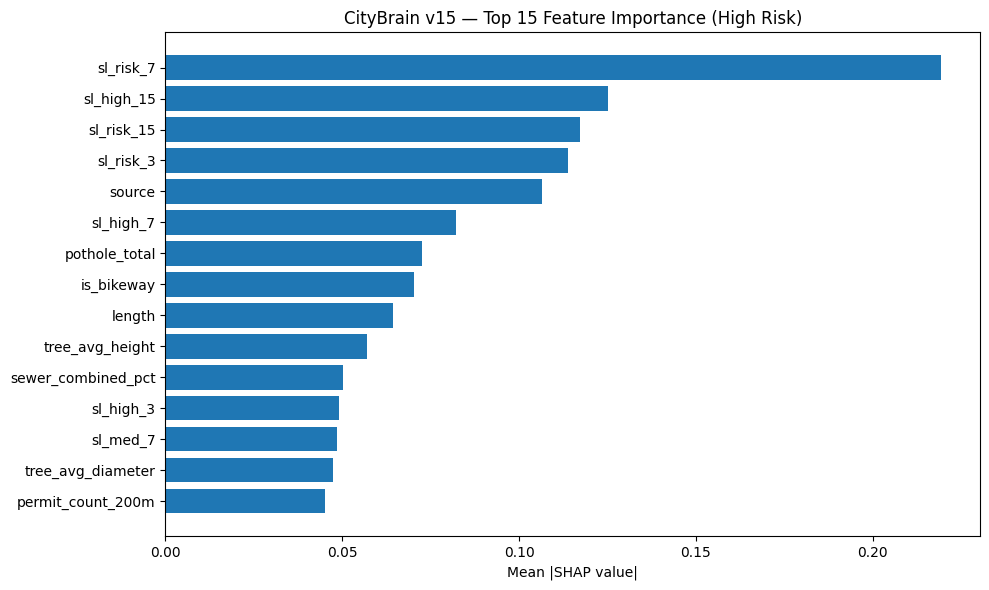

Saved shap_importance_v15.png


In [59]:
print(f'\n{"="*60}')
print('SHAP Feature Importance')
print(f'{"="*60}')

try:
    import shap
    print('Computing SHAP values on last-fold XGBoost (base model, original features)...')

    # Use the LAST fold's XGBoost model (xgb_fold) — it has original features
    explainer = shap.TreeExplainer(xgb_fold)
    sample_size = min(500, len(X_test_flat))
    shap_values = explainer.shap_values(X_test_flat[:sample_size])
    print('SHAP values computed')

    # Feature names match X_pool columns: road + tab_cont + neigh_index
    R_DIM = X_road_raw.shape[1]
    road_names = ['length', 'su_Arterial', 'su_Collector', 'su_Residential',
                  'elevation', 'slope', 'source', 'ROW_width',
                  'is_truck_route', 'is_snow_route', 'is_bikeway', 'speed_limit']
    tab_names = [
        'repair_count', 'segment_density', 'dist_to_traffic',
        'sl_risk_3', 'sl_high_3', 'sl_risk_7', 'sl_high_7', 'sl_med_7',
        'sl_risk_15', 'sl_high_15',
        'neigh_low_pct', 'neigh_med_pct', 'neigh_high_pct',
        'complaint_total', 'pothole_total', 'complaint_recent_3m', 'complaint_accel',
        'complaint_density', 'sl_complaints',
        'annual_precip', 'annual_snow', 'annual_freeze', 'annual_extreme',
        'annual_temp_range', 'prev_yr_precip', 'prev_yr_freeze',
        'precip_x_slope', 'freeze_x_street', 'snow_x_slope', 'temprange_x_street',
        'water_main_count', 'water_main_avg_age',
        'sewer_main_count', 'sewer_combined_pct',
        'tree_count_30m', 'tree_avg_diameter', 'tree_avg_height',
        'is_industrial', 'is_commercial',
        'permit_count_200m', 'permit_avg_value',
        'manhole_count_50m', 'catch_basin_count_50m',
        'bus_frequency',
        'est_pavement_age', 'est_age_imputed', 'traffic_load_proxy', 'utility_density',
        'manholes_per_100m', 'trees_per_100m', 'water_mains_per_100m',
        'catch_basins_per_100m', 'tree_root_pressure',
        'drainage_risk', 'pipe_freeze_risk',
        'neighbourhood']
    all_names = road_names + tab_names

    if isinstance(shap_values, list):
        sv = shap_values[2]  # High-risk class
    else:
        sv = shap_values[:, :, 2] if shap_values.ndim == 3 else shap_values
    mean_abs = np.abs(sv).mean(axis=0)

    road_imp = mean_abs[:R_DIM].sum()
    tab_imp = mean_abs[R_DIM:].sum()
    total_imp = road_imp + tab_imp
    print(f'\n{"="*55}')
    print('SHAP Branch-Level Importance (High-risk class)')
    print(f'{"="*55}')
    print(f'  Road features:    {road_imp/total_imp*100:.1f}%')
    print(f'  Tabular features: {tab_imp/total_imp*100:.1f}%')

    top_idx = np.argsort(mean_abs)[::-1][:15]
    print(f'\nTop 15 features by mean |SHAP|:')
    for i, idx in enumerate(top_idx):
        idx = int(idx)
        name = all_names[idx] if idx < len(all_names) else f'feature_{idx}'
        print(f'  {i+1:>2}. {name:<30} {mean_abs[idx]:.4f}')

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 6))
    top_names_plot = [all_names[int(i)] if int(i) < len(all_names) else f'f_{i}' for i in top_idx[:15]]
    top_vals = [mean_abs[int(i)] for i in top_idx[:15]]
    ax.barh(range(15), top_vals[::-1])
    ax.set_yticks(range(15)); ax.set_yticklabels(top_names_plot[::-1])
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('CityBrain v15 — Top 15 Feature Importance (High Risk)')
    plt.tight_layout(); plt.savefig('shap_importance_v15.png', dpi=150); plt.show()
    print('Saved shap_importance_v15.png')
except Exception as e:
    print(f'SHAP analysis failed: {e}')

## 18b. Performance Visualisation Charts ★ v15 ★

1. Confusion matrix heatmap  2. Per-class F1 by model  3. Version history bar chart

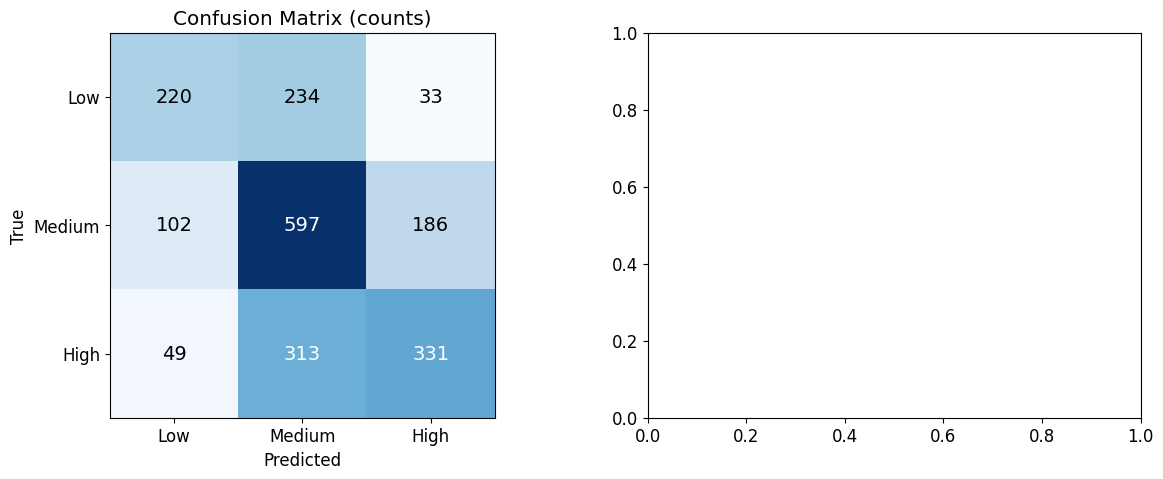

In [60]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12

# --- Chart 1: Confusion Matrix Heatmap ---
final_preds_viz = preds_tuned if tuned_f1 >= ens_f1 else best_probs.argmax(1)
cm_viz = confusion_matrix(y_te, final_preds_viz)
cm_pct = cm_viz.astype(float) / cm_viz.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
im = axes[0].imshow(cm_viz, cmap='Blues')
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(CLASS_NAMES); axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (counts)')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, str(cm_viz[i, j]), ha='center', va='center',
                     color='white' if cm_viz[i, j] > cm_viz.max()/2 else 'black', fontsize=14)

<Figure size 640x480 with 0 Axes>

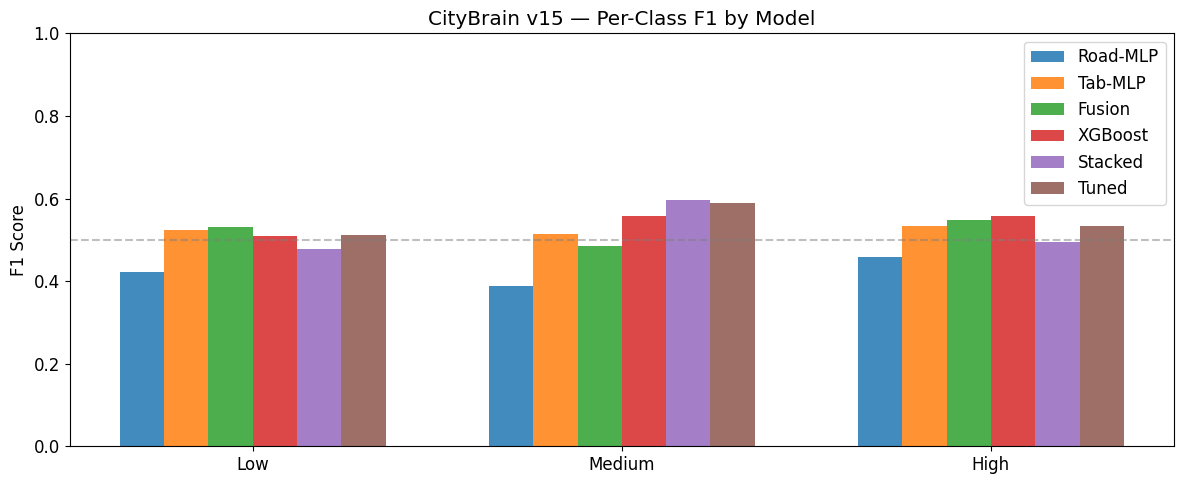

In [61]:
# Percentages
im2 = axes[1].imshow(cm_pct, cmap='Oranges', vmin=0, vmax=100)
axes[1].set_xticks(range(3)); axes[1].set_yticks(range(3))
axes[1].set_xticklabels(CLASS_NAMES); axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (row-normalised %)')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{cm_pct[i, j]:.1f}%', ha='center', va='center',
                     color='white' if cm_pct[i, j] > 50 else 'black', fontsize=14)

plt.suptitle('CityBrain v15 — Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrix_v15.png', dpi=150); plt.show()

# --- Chart 2: Per-Class F1 Comparison (all v15 models) ---
model_names = ['Road-MLP', 'Tab-MLP', 'Fusion', 'XGBoost', 'Stacked', 'Tuned']
from sklearn.metrics import f1_score as f1s
model_preds_list = [
    (eval_test(road_model, Xr_te, y_te)[1], 'Road-MLP'),
    (eval_test(tab_model, Xb_te, y_te)[1], 'Tab-MLP'),
    (preds, 'Fusion'),
    (test_probs_xgb_avg.argmax(1), 'XGBoost'),
    (stacked_preds, 'Stacked'),
    (final_preds_viz, 'Tuned'),
]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(3)
width = 0.12
for idx_m, (mpreds, mname) in enumerate(model_preds_list):
    per_class = [f1s(y_te == c, mpreds == c, zero_division=0) for c in range(3)]
    ax.bar(x + idx_m * width, per_class, width, label=mname, alpha=0.85)
ax.set_xticks(x + width * 2.5); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1 Score'); ax.set_title('CityBrain v15 — Per-Class F1 by Model')
ax.legend(loc='upper right'); ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig('per_class_f1_v15.png', dpi=150); plt.show()

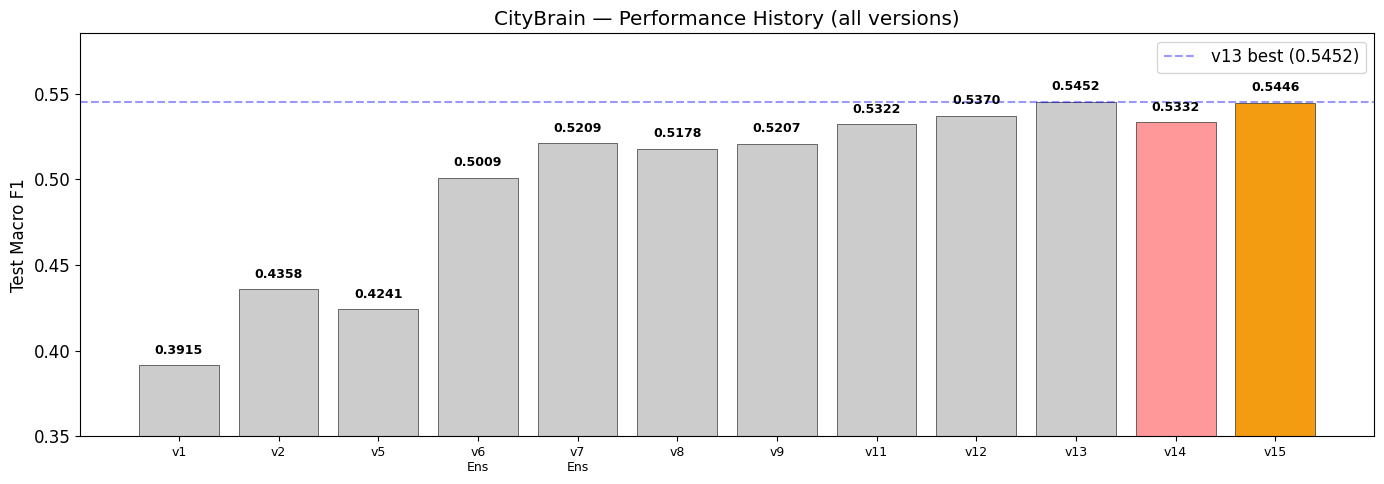

Charts saved: confusion_matrix_v15.png, per_class_f1_v15.png, version_history_v15.png


In [62]:
# --- Chart 3: Version History ---
best_test = max(ens_f1, tuned_f1)
versions = ['v1','v2','v5','v6\nEns','v7\nEns','v8','v9','v11','v12','v13','v14','v15']
scores =   [0.3915, 0.4358, 0.4241, 0.5009, 0.5209, 0.5178, 0.5207, 0.5322, 0.5370, 0.5452, 0.5332, best_test]
colors = ['#cccccc']*10 + ['#ff9999', '#2ecc71' if best_test > 0.5452 else '#f39c12']

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(versions)), scores, color=colors, edgecolor='#333', linewidth=0.5)
for i, (v, s) in enumerate(zip(versions, scores)):
    ax.text(i, s + 0.005, f'{s:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(versions))); ax.set_xticklabels(versions, fontsize=9)
ax.set_ylabel('Test Macro F1'); ax.set_title('CityBrain — Performance History (all versions)')
ax.set_ylim(0.35, max(scores) + 0.04)
ax.axhline(y=0.5452, color='blue', linestyle='--', alpha=0.4, label='v13 best (0.5452)')
ax.legend()
plt.tight_layout(); plt.savefig('version_history_v15.png', dpi=150); plt.show()

print('Charts saved: confusion_matrix_v15.png, per_class_f1_v15.png, version_history_v15.png')

## 19. Final Comparison — All Versions

In [63]:
all_results = [ens_f1, tuned_f1]
best_name = 'Threshold-Tuned Ensemble' if tuned_f1 >= ens_f1 else 'Best Ensemble'
best_test = max(all_results)

print(f'\n{"="*60}')
print('FINAL COMPARISON — ALL VERSIONS')
print(f'{"="*60}')
print(f'{"Model":<55} {"Test Macro F1":>12}')
print('-'*69)
print(f'{"v1 Baseline (old 3-class, concat fusion)":<55} {"0.3915":>12}')
print(f'{"v2 Enhanced (old 3-class)":<55} {"0.4358":>12}')
print(f'{"v5 GatedFusion (rebalanced)":<55} {"0.4241":>12}')
print(f'{"v6 CrossAttention Fusion":<55} {"0.4400":>12}')
print(f'{"v6 Simple Ensemble (Fusion+XGB)":<55} {"0.5009":>12}')
print(f'{"v7 3-Branch Fusion":<55} {"0.5145":>12}')
print(f'{"v7 2-Model Ensemble (Fusion+XGB)":<55} {"0.5209":>12}')
print(f'{"v8 Threshold-Tuned Ensemble":<55} {"0.5178":>12}')
print(f'{"v9 Threshold-Tuned Ensemble":<55} {"0.5207":>12}')
print(f'{"v11 Best Ensemble (18 infra features)":<55} {"0.5322":>12}')
print(f'{"v12 Stacked Meta-Learner (best)":<55} {"0.5370":>12}')
print(f'{"v13 Best (SMOTE-ENN)":<55} {"0.5452":>12}')
print(f'{"v14 Best (no resampling, balanced weights)":<55} {"0.5332":>12}')
print(f'---')
print(f'{"v15 Road-MLP (12d, residual blocks)":<55} {road_test:>12.4f}')
print(f'{"v15 Tabular-MLP (55d, +age indicator)":<55} {tab_test:>12.4f}')
print(f'{"v15 2-Branch Fusion (d_model=64, 2-layer)":<55} {test_f1:>12.4f}')
print(f'{"v15 10-Fold XGBoost (balanced+Optuna)":<55} {xgb_test_f1:>12.4f}')
if HAS_LGBM:
    print(f'{"v15 10-Fold LightGBM (balanced+Optuna)":<55} {lgbm_test_f1:>12.4f}')
if HAS_CATBOOST:
    print(f'{"v15 10-Fold CatBoost (auto balanced)":<55} {cb_test_f1:>12.4f}')
print(f'{"v15 10-Fold ExtraTrees (balanced)":<55} {et_test_f1:>12.4f}')
if HAS_TABPFN:
    print(f'{"v15 10-Fold TabPFN":<55} {tpfn_test_f1:>12.4f}')
n_base = 3 + int(HAS_CATBOOST) + int(HAS_TABPFN)
print(f'{"v15 Stacked Meta-Learner (" + str(n_base) + " models, reg)":<55} {stacked_f1:>12.4f}')
print(f'{"v15 Best Ensemble (" + best_ens_name + ")":<55} {ens_f1:>12.4f}')
print(f'{"★ v15 Threshold-Tuned (DE-refined)":<55} {tuned_f1:>12.4f}')
print(f'\n{"="*60}')
print(f'BEST: {best_name} = {best_test:.4f}')
print(f'Improvement over v13: {best_test - 0.5452:+.4f}')
print(f'{"="*60}')

print(f'\nAll {len(df):,} samples used.')
print(f'v15 key changes:')
print(f'  1. SMOTE-only (no ENN) — oversample minority, keep all originals')
print(f'  2. Regularised meta-learner (max_depth=2, reg_alpha=1, reg_lambda=2)')
print(f'  3. class_weight=balanced + sample_weight for all tree models')
print(f'  4. Finer threshold tuning (0.02 grid + differential_evolution)')
print(f'  5. Performance visualisation charts')


FINAL COMPARISON — ALL VERSIONS
Model                                                   Test Macro F1
---------------------------------------------------------------------
v1 Baseline (old 3-class, concat fusion)                      0.3915
v2 Enhanced (old 3-class)                                     0.4358
v5 GatedFusion (rebalanced)                                   0.4241
v6 CrossAttention Fusion                                      0.4400
v6 Simple Ensemble (Fusion+XGB)                               0.5009
v7 3-Branch Fusion                                            0.5145
v7 2-Model Ensemble (Fusion+XGB)                              0.5209
v8 Threshold-Tuned Ensemble                                   0.5178
v9 Threshold-Tuned Ensemble                                   0.5207
v11 Best Ensemble (18 infra features)                         0.5322
v12 Stacked Meta-Learner (best)                               0.5370
v13 Best (SMOTE-ENN)                                          0.5452

## 20. Interactive Prediction Map (Plotly) ★ v15 ★

Scatter-mapbox of test-set predictions over Vancouver.
Hover for per-road features & class probabilities.

**Requires:** `pip install plotly` (pre-installed on Colab).

In [77]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

In [79]:
print("\n" + "="*60)
print("CityBrain v15 - Interactive Prediction Map (Plotly)")
print("="*60)

# --- 20a. Prepare data from existing variables ---
n_show = min(3000, len(idx_test))

show_lat = df['lat'].values[idx_test][:n_show]
show_lon = df['lon'].values[idx_test][:n_show]

if 'preds_tuned' in dir() and preds_tuned is not None:
    show_pred = preds_tuned[:n_show]
    pred_name = "Threshold-Tuned Ensemble"
    pred_f1 = tuned_f1
elif 'stacked_preds' in dir() and stacked_preds is not None:
    show_pred = stacked_preds[:n_show]
    pred_name = "Stacked Meta-Learner"
    pred_f1 = stacked_f1
elif 'ens_b_f1_test' in dir():
    show_pred = ens_b_probs.argmax(1)[:n_show] if 'ens_b_probs' in dir() else preds[:n_show]
    pred_name = "Stacked+Fusion Ensemble"
    pred_f1 = ens_b_f1_test if 'ens_b_f1_test' in dir() else 0.54
else:
    print("Re-predicting test set...")
    with torch.no_grad():
        logits = fusion(torch.tensor(Xr_te[:n_show]).to(DEVICE),
                        torch.tensor(Xb_te[:n_show]).to(DEVICE))
        show_pred = logits.argmax(1).cpu().numpy()
    pred_name = "2-Branch Fusion"
    pred_f1 = test_f1

show_true = y_te[:n_show]

show_traffic = df['traffic_load_proxy'].values[idx_test][:n_show]
show_age = df['est_pavement_age'].values[idx_test][:n_show]
show_streetuse = df['streetuse'].values[idx_test][:n_show]
show_length = df['length_(m)'].values[idx_test][:n_show]
show_water_age = df['water_main_avg_age'].values[idx_test][:n_show]
show_truck = df['is_truck_route'].values[idx_test][:n_show]
show_snow = df['is_snow_route'].values[idx_test][:n_show]

if 'stacked_probs' in dir() and stacked_probs is not None:
    show_probs = stacked_probs[:n_show]
elif 'test_probs_fusion' in dir() and test_probs_fusion is not None:
    show_probs = test_probs_fusion[:n_show]
else:
    show_probs = None

# --- 20b. Build DataFrame ---
import plotly.graph_objects as go
import plotly.express as px

class_names_map = ['Low Risk', 'Medium Risk', 'High Risk']
color_map = {
    'Low Risk': '#2ecc71',
    'Medium Risk': '#f39c12',
    'High Risk': '#e74c3c'
}

results_df = pd.DataFrame({
    'lat': show_lat,
    'lon': show_lon,
    'Prediction': [class_names_map[p] for p in show_pred],
    'Prediction_Code': show_pred,
    'True_Label': [class_names_map[t] for t in show_true],
    'Correct': show_pred == show_true,
    'Traffic_Load': show_traffic,
    'Est_Pavement_Age': show_age,
    'Street_Type': show_streetuse,
    'Length_m': show_length,
    'Water_Main_Age': show_water_age,
    'Truck_Route': ['Y' if x else 'N' for x in show_truck],
    'Snow_Route': ['Y' if x else 'N' for x in show_snow],
})

if show_probs is not None:
    results_df['Prob_Low'] = show_probs[:, 0]
    results_df['Prob_Medium'] = show_probs[:, 1]
    results_df['Prob_High'] = show_probs[:, 2]

accuracy = (results_df['Correct'].mean() * 100)
print(f"\nDisplaying {len(results_df):,} road segments")
print(f"Prediction Accuracy: {accuracy:.1f}%")
print(f"Best Model: {pred_name} (Macro F1: {pred_f1:.4f})")

print("\nPrediction Distribution:")
for i, name in enumerate(class_names_map):
    cnt = (show_pred == i).sum()
    print(f"   {name}: {cnt:,} ({cnt/len(show_pred)*100:.1f}%)")

# --- 20c. Custom Hover Template ---
hover_base = (
    "<b>Road Segment</b><br>"
    "<b>Prediction:</b> <span style='color:{}'>{}</span><br>"
    "<b>True Label:</b> {}<br>"
    "<b>Correct:</b> {}<br>"
    "<b>Traffic Load:</b> {:.2f}<br>"
    "<b>Est. Pavement Age:</b> {:.0f} years<br>"
    "<b>Street Type:</b> {}<br>"
    "<b>Length:</b> {:.0f} m<br>"
    "<b>Water Main Age:</b> {:.0f} years<br>"
    "<b>Truck Route:</b> {}<br>"
    "<b>Snow Route:</b> {}<br>"
)

hover_prob = (
    "<b>Prediction Probabilities:</b><br>"
    "<span style='color:#2ecc71'>Low:</span> {:.1f}%<br>"
    "<span style='color:#f39c12'>Medium:</span> {:.1f}%<br>"
    "<span style='color:#e74c3c'>High:</span> {:.1f}%<br>"
)

if show_probs is not None:
    hover_template = hover_base + hover_prob
    results_df['hover_text'] = results_df.apply(lambda row: hover_template.format(
        color_map[row['Prediction']], row['Prediction'], row['True_Label'],
        'Yes' if row['Correct'] else 'No',
        row['Traffic_Load'], row['Est_Pavement_Age'], row['Street_Type'],
        row['Length_m'], row['Water_Main_Age'], row['Truck_Route'], row['Snow_Route'],
        row['Prob_Low']*100, row['Prob_Medium']*100, row['Prob_High']*100
    ), axis=1)
else:
    results_df['hover_text'] = results_df.apply(lambda row: hover_base.format(
        color_map[row['Prediction']], row['Prediction'], row['True_Label'],
        'Yes' if row['Correct'] else 'No',
        row['Traffic_Load'], row['Est_Pavement_Age'], row['Street_Type'],
        row['Length_m'], row['Water_Main_Age'], row['Truck_Route'], row['Snow_Route']
    ), axis=1)

# --- 20d. Create Interactive Map ---
fig = px.scatter_mapbox(
    results_df,
    lat='lat',
    lon='lon',
    color='Prediction',
    color_discrete_map=color_map,
    hover_name=None,
    hover_data={'hover_text': True},
    title=f"<b>CityBrain v15</b> — Vancouver Pavement Condition Prediction<br>" +
          f"<sup>Model: {pred_name} | Macro F1: {pred_f1:.4f} | " +
          f"Accuracy: {accuracy:.1f}% | {len(results_df):,} road segments shown</sup>",
    zoom=11,
    height=750,
    width=None,
)

fig.update_traces(
    marker=dict(size=6, opacity=0.85),
    selector=dict(mode='markers')
)

fig.update_layout(
    mapbox_style="carto-positron",
    mapbox=dict(center=dict(lat=49.25, lon=-123.12), zoom=11),
    margin=dict(r=0, t=80, l=0, b=0),
    legend=dict(
        title=dict(text="Risk Level", font=dict(size=14)),
        orientation="v", yanchor="top", y=0.99, xanchor="left", x=0.01,
        bgcolor="rgba(255,255,255,0.9)", bordercolor="black", borderwidth=1,
        font=dict(size=12)
    ),
    title=dict(font=dict(size=18, family='Arial'), x=0.5, xanchor='center'),
    hoverlabel=dict(bgcolor="white", font_size=12, font_family="Arial", bordercolor="black")
)

# High-risk glow layer (hoverinfo='skip' so it doesn't block real tooltips)
glow = px.scatter_mapbox(
    results_df[results_df['Prediction'] == 'High Risk'],
    lat='lat', lon='lon',
    color_discrete_sequence=['rgba(231, 76, 60, 0.3)']
).data[0]
glow.hoverinfo = 'skip'
glow.hovertemplate = None
fig.add_trace(glow)

# --- 20e. Model history annotation ---
fig.add_annotation(
    text="<b>Model Performance</b><br>" +
         "v1 Baseline: 0.3915<br>" +
         "v11: 0.5322<br>" +
         "v12: 0.5370<br>" +
         "v13: 0.5452<br>" +
         "v14: 0.5332<br>" +
         f"<b>v15 ({pred_name}): {pred_f1:.4f}</b>",
    xref="paper", yref="paper",
    x=0.98, y=0.02,
    showarrow=False, align="right",
    bgcolor="rgba(255,255,255,0.9)", bordercolor="#333",
    borderwidth=1, borderpad=8, font=dict(size=11)
)

# --- 20f. Save and Display ---
fig.write_html("citybrain_v15_prediction_map.html")
print("\n" + "="*60)
print("Interactive map saved as: citybrain_v15_prediction_map.html")
print("Download and open in browser for full interactivity")
print("="*60)

fig.show()

# --- 20g. Summary Statistics ---
print("\n" + "="*60)
print("CONFUSION MATRIX SUMMARY (Map Subset)")
print("="*60)

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
cm_map = confusion_matrix(show_true, show_pred)
print("\n" + " " * 12 + "Predicted")
print(" " * 12 + f"{'Low':>8} {'Medium':>10} {'High':>8}")
for i, true_name in enumerate(class_names_map):
    print(f"True {true_name:<12} {cm_map[i,0]:>8} {cm_map[i,1]:>10} {cm_map[i,2]:>8}")

prec_map, rec_map, f1_map, _ = precision_recall_fscore_support(show_true, show_pred, average=None)
print("\nPer-Class Metrics:")
print(f"{'Class':<14} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 47)
for i, name in enumerate(class_names_map):
    print(f"{name:<14} {prec_map[i]:>10.4f} {rec_map[i]:>10.4f} {f1_map[i]:>10.4f}")
print("-" * 47)
print(f"{'Macro Avg':<14} {prec_map.mean():>10.4f} {rec_map.mean():>10.4f} {f1_map.mean():>10.4f}")

print("\n" + "="*60)
print("CityBrain v15 Visualization Complete!")
print("="*60)


CityBrain v15 - Interactive Prediction Map (Plotly)

Displaying 2,065 road segments
Prediction Accuracy: 55.6%
Best Model: Threshold-Tuned Ensemble (Macro F1: 0.5446)

Prediction Distribution:
   Low Risk: 371 (18.0%)
   Medium Risk: 1,144 (55.4%)
   High Risk: 550 (26.6%)

Interactive map saved as: citybrain_v15_prediction_map.html
Download and open in browser for full interactivity



CONFUSION MATRIX SUMMARY (Map Subset)

            Predicted
                 Low     Medium     High
True Low Risk          220        234       33
True Medium Risk       102        597      186
True High Risk          49        313      331

Per-Class Metrics:
Class           Precision     Recall   F1-Score
-----------------------------------------------
Low Risk           0.5930     0.4517     0.5128
Medium Risk        0.5219     0.6746     0.5885
High Risk          0.6018     0.4776     0.5326
-----------------------------------------------
Macro Avg          0.5722     0.5347     0.5446

CityBrain v15 Visualization Complete!
